# Factor Score Exploration

Descriptive statistics, distributions, and temporal trajectories for the 10 EFA factors.

In [79]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.0)

### Factor	Name	% var	Interpretation (high score = more of...)

F1	Syntactic Complexity	8.5%	subordination/coordination, parse depth, sentence-length variability, readability (sentence-length component)

F2	Lexical Sophistication	6.6%	syllable length, AoA, harder-vocabulary readability indices, fewer pronouns/CCONJ

F3	Negative Affect	6.6%	anger, fear, sadness, disgust, valence variance, low mean valence

F4	Lexical Richness	5.8%	unique tokens, topic strength, semantic volume, max cluster share, low duplication

F5	Repetitiveness	5.5%	top n-gram fractions, duplication, OOV, low alpha-ratio, fewer modifiers

F6	Concreteness	5.2%	concreteness, nouns, low auxiliaries/particles/adverbs

F7	Conversationality	5.1%	interjections, questions, quotations, exclamations, dependency-distance variability

F8	Positive Affect	3.7%	joy, trust, anticipation, positive valence

F9	Narrative Drift	3.5%	semantic dispersion, drift, transition variability

F10	Structural Variability	3.2%	sentence/dependency/parse-depth std, mixed POS signal*

\* overlaps with F1 (`sentence_length_std`) and F7 (`dependency_distance_std`), which are also salient there so likely picking up leftover variability variance rather than a fully distinct construct.

In [80]:
PROJECT_ROOT = Path('/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper')
SCORES_PATH  = PROJECT_ROOT / 'data' / 'efa_factor_scores.csv'
VIS_DIR      = PROJECT_ROOT / 'outputs' / 'visualizations' / 'factor_explore'
VIS_DIR.mkdir(parents=True, exist_ok=True)

FACTOR_NAMES = {
    'F1':  'Syntactic Complexity',
    'F2':  'Lexical Sophistication',
    'F3':  'Negative Affect',
    'F4':  'Lexical Richness',
    'F5':  'Repetitiveness',
    'F6':  'Concreteness',
    'F7':  'Conversationality',
    'F8':  'Positive Affect',
    'F9':  'Narrative Drift',
    'F10': 'Structural Variability',
}

df = pd.read_csv(SCORES_PATH, parse_dates=['published'])
FACTOR_COLS = [c for c in df.columns if c.startswith('F') and c[1:].isdigit()]

# Drop rows where EFA filtering removed the text (no factor scores)
n_before = len(df)
df = df.dropna(subset=FACTOR_COLS).reset_index(drop=True)
print(f"Loaded: {n_before} rows → {len(df)} after dropping NaN factor rows")
print(f"Date range: {df['published'].min().date()} → {df['published'].max().date()}")
df.head(3)

Loaded: 16966 rows → 16966 after dropping NaN factor rows
Date range: 2000-04-30 → 2026-01-05


,id,title,author,fandom,published,rating,words,chapters,fandom_label,source,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,53262055,river styx is high and wide,MelittaRilow,"['Hadestown - Mitchell', 'Ancient Greek Religi...",2024-01-24,['Mature'],8057.0,1/1,random,human,-0.186773,-0.700984,0.837594,-0.918279,-1.176615,1.058944,0.315300,0.570249,0.710319,1.480933
1,51560773,heard you got it so bad (i'm the best you'll n...,Anonymous,['Fall Out Boy'],2023-11-13,['Explicit'],5445.0,1/1,random,human,0.813925,-0.948484,-0.272240,-0.654175,-0.715007,1.149996,0.098757,-0.967251,-1.151534,-0.413066
2,51526354,Sisters,niamsagram,['The Rookie (TV 2018)'],2023-11-11,['General Audiences'],1351.0,1/1,random,human,-1.271360,-3.546188,-1.369806,0.702360,-0.007880,0.335195,0.538533,0.782028,-0.941722,-0.670490


## 1. Descriptive statistics

In [81]:
desc = df[FACTOR_COLS].describe().T
desc.insert(0, 'name', [FACTOR_NAMES[f] for f in desc.index])
desc['skew']     = df[FACTOR_COLS].skew()
desc['kurtosis'] = df[FACTOR_COLS].kurtosis()
desc = desc[['name', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']]
desc.round(3)

,name,mean,std,min,25%,50%,75%,max,skew,kurtosis
F1,Syntactic Complexity,-0.0,0.995,-4.003,-0.630,-0.016,0.619,4.460,0.118,0.657
F2,Lexical Sophistication,-0.0,0.990,-3.935,-0.626,0.002,0.623,5.133,0.023,0.670
F3,Negative Affect,0.0,0.972,-3.933,-0.671,-0.005,0.650,3.683,0.059,-0.072
F4,Lexical Richness,0.0,0.985,-2.354,-0.723,0.028,0.751,3.295,-0.082,-0.646
F5,Repetitiveness,-0.0,0.965,-2.570,-0.687,-0.096,0.590,5.281,0.632,0.765
F6,Concreteness,0.0,0.975,-4.022,-0.646,-0.002,0.633,4.092,0.030,0.226
F7,Conversationality,0.0,0.966,-4.876,-0.627,0.035,0.650,3.993,-0.181,0.323
F8,Positive Affect,-0.0,0.947,-3.095,-0.649,-0.099,0.551,5.042,0.620,0.812
F9,Narrative Drift,0.0,0.954,-3.688,-0.655,0.023,0.684,3.227,-0.120,-0.215
F10,Structural Variability,0.0,0.970,-6.947,-0.613,-0.010,0.614,8.717,0.151,1.693


## 2. Distributions

Histogram + KDE for each factor. Factor scores from oblique EFA (oblimin) are not orthogonal, so some correlation across factors is expected.

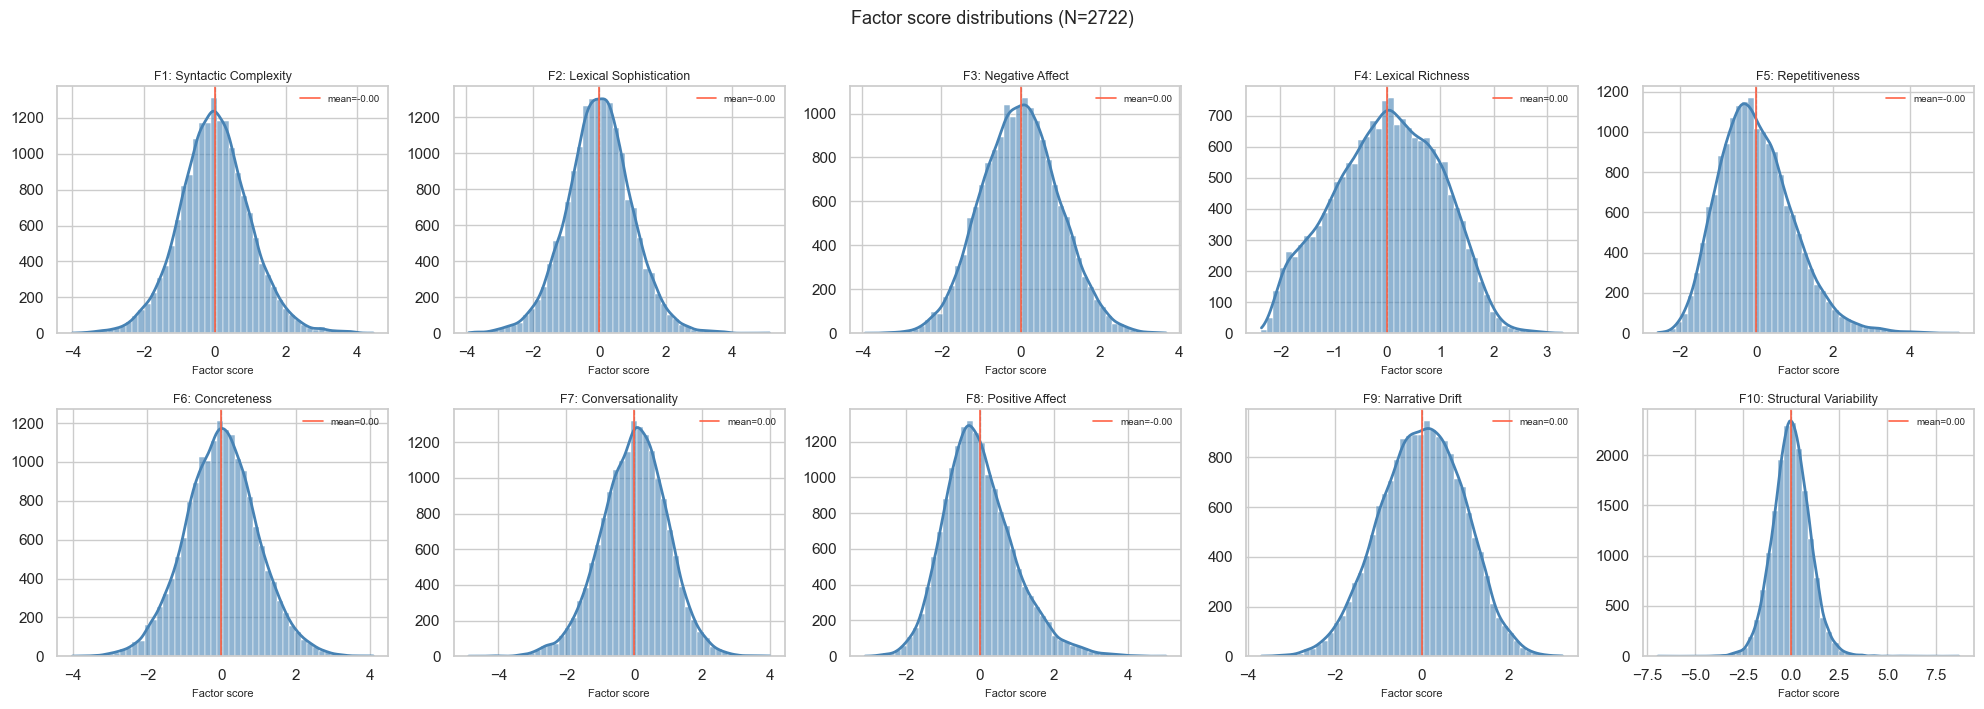

In [82]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=False)
axes = axes.flatten()

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    sns.histplot(df[f], kde=True, ax=ax, color='steelblue', bins=50, alpha=0.6, line_kws={'lw': 2})
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.axvline(df[f].mean(), color='tomato', linewidth=1.2, linestyle='-', label=f'mean={df[f].mean():.2f}')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=9, pad=4)
    ax.set_xlabel('Factor score', fontsize=8)
    ax.set_ylabel('')
    ax.legend(fontsize=7, frameon=False)

plt.suptitle('Factor score distributions (N=2722)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

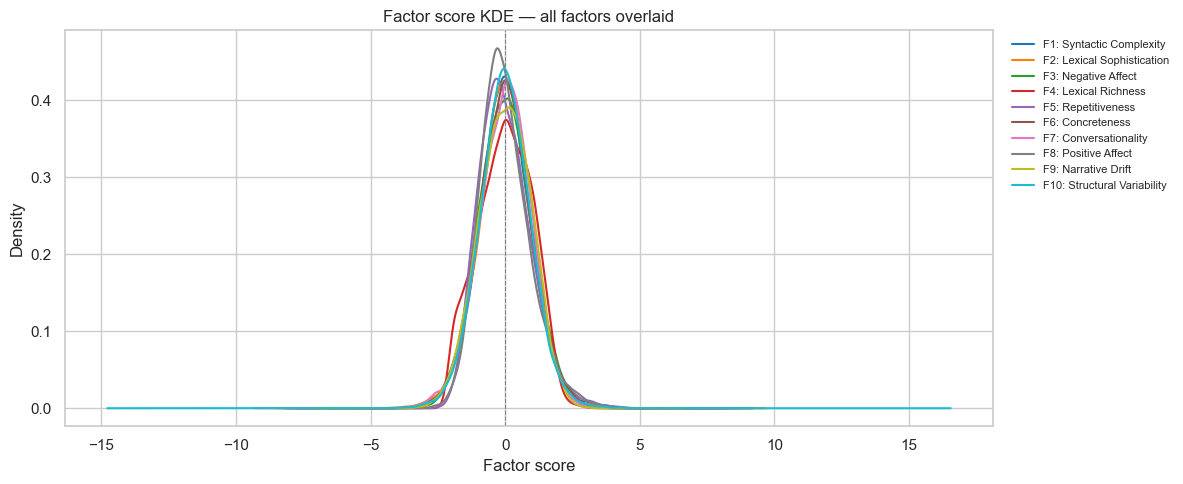

In [83]:
# KDE overlay — all factors on one plot to compare spread and centre
fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', n_colors=len(FACTOR_COLS))

for i, f in enumerate(FACTOR_COLS):
    df[f].plot.kde(ax=ax, color=palette[i], label=f'{f}: {FACTOR_NAMES[f]}', linewidth=1.5)

ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Factor score')
ax.set_ylabel('Density')
ax.set_title('Factor score KDE — all factors overlaid')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_distributions_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Factor intercorrelations

Oblimin rotation allows correlated factors. This shows how much they actually correlate in the data.

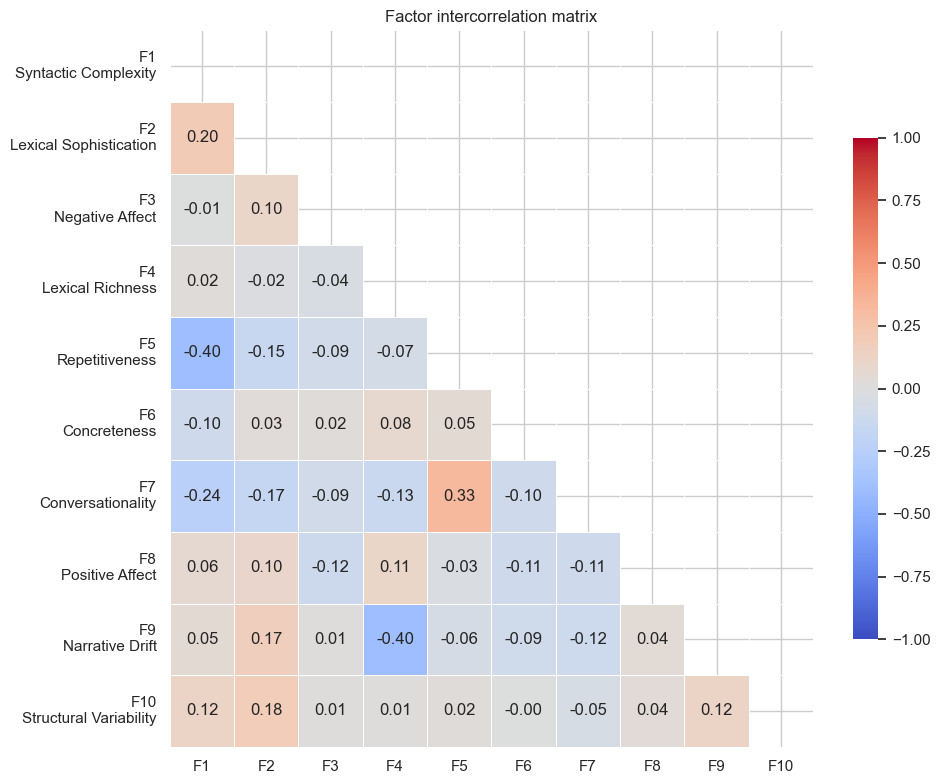

In [84]:
corr = df[FACTOR_COLS].corr()

labels = [f'{f}\n{FACTOR_NAMES[f]}' for f in FACTOR_COLS]
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    xticklabels=[f for f in FACTOR_COLS],
    yticklabels=labels,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Factor intercorrelation matrix')
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_intercorrelations.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Trajectory over time

Mean factor score per month across all texts. Shaded band = ±1 SE.

In [85]:
df['year_month'] = df['published'].dt.to_period('M')

monthly_mean = df.groupby('year_month')[FACTOR_COLS].mean()
monthly_se   = df.groupby('year_month')[FACTOR_COLS].sem()
monthly_n    = df.groupby('year_month')[FACTOR_COLS[0]].count().rename('n')

# Convert period index to timestamp for plotting
dates = monthly_mean.index.to_timestamp()

print(f"Monthly bins: {len(monthly_mean)}")
print(monthly_n.sort_index().to_string())

Monthly bins: 281
year_month
2000-04      1
2002-01      1
2002-02      3
2002-06      1
2002-07      1
2002-08      1
2002-09      3
2002-10      3
2002-12      1
2003-01      4
2003-02      2
2003-03      5
2003-04      1
2003-05      2
2003-07      1
2003-08      1
2003-10      2
2003-11      2
2004-01      1
2004-02      3
2004-03      3
2004-04      1
2004-06      5
2004-08      5
2004-09      1
2004-10      4
2004-11      5
2004-12      3
2005-01      8
2005-02      5
2005-03      4
2005-04      2
2005-05      1
2005-06      4
2005-07      6
2005-08      1
2005-09      2
2005-10      3
2005-11      6
2005-12      5
2006-01      3
2006-02      5
2006-03      8
2006-04      4
2006-05      8
2006-06      7
2006-07      3
2006-08      6
2006-09      8
2006-10      3
2006-11      8
2006-12      7
2007-01      5
2007-02      3
2007-03      8
2007-04      5
2007-05      5
2007-06      7
2007-07      3
2007-08      9
2007-09      7
2007-10      8
2007-11      2
2007-12      4
2008-01    

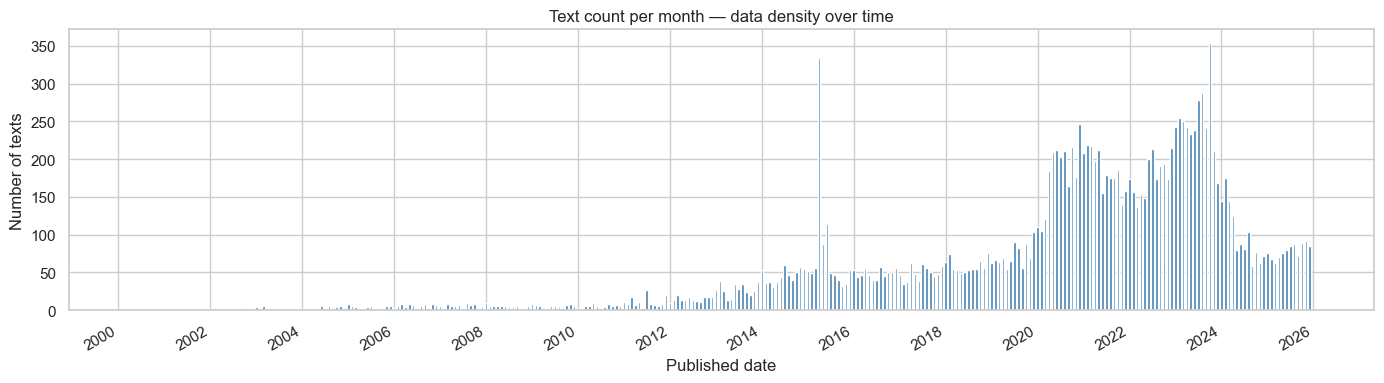

In [86]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(dates, monthly_n.values, width=20, color='steelblue', edgecolor='white')
ax.set_xlabel('Published date')
ax.set_ylabel('Number of texts')
ax.set_title('Text count per month — data density over time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(VIS_DIR / 'texts_per_month_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

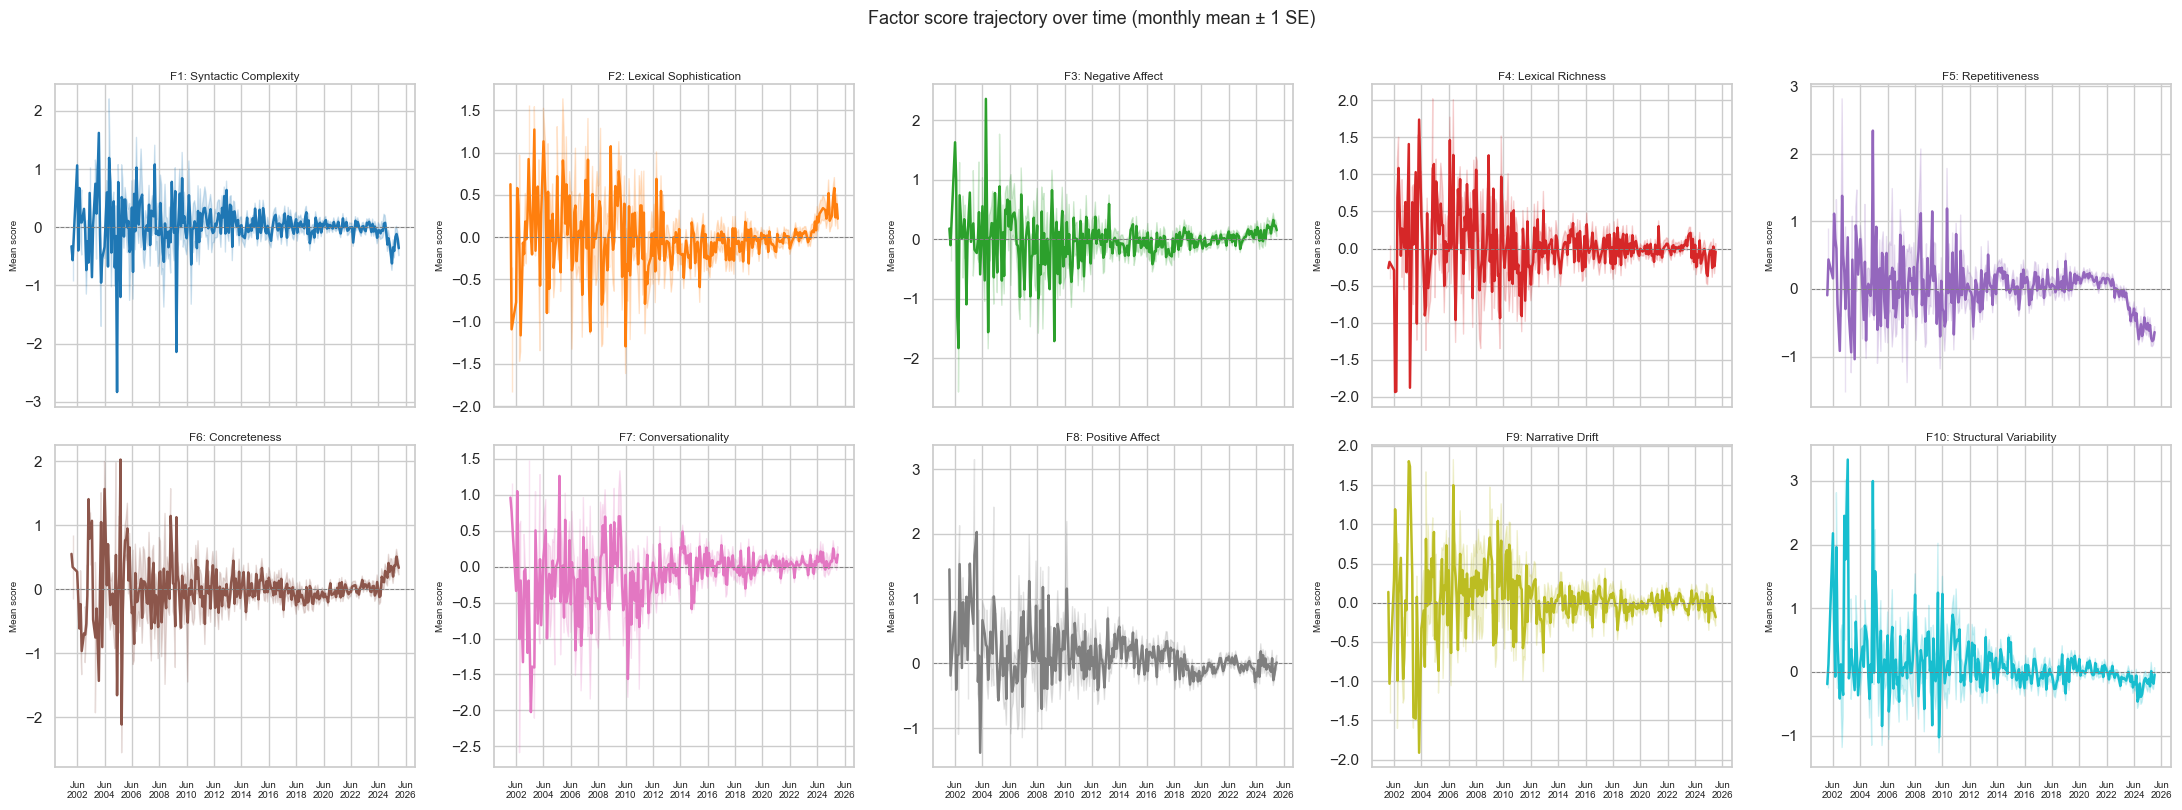

In [87]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', n_colors=len(FACTOR_COLS))

# Trim first and last month (2022-12: n=1, 2026-01: n=2 — too sparse)
dates_trim = dates[1:-1]

for i, f in enumerate(FACTOR_COLS):
    ax    = axes[i]
    mean  = monthly_mean[f].values[1:-1]
    se    = monthly_se[f].values[1:-1]
    color = palette[i]

    ax.plot(dates_trim, mean, color=color, linewidth=1.8)
    ax.fill_between(dates_trim, mean - se, mean + se, color=color, alpha=0.2)
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
    ax.tick_params(axis='x', labelsize=7)
    ax.set_ylabel('Mean score', fontsize=7)

plt.suptitle('Factor score trajectory over time (monthly mean ± 1 SE)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_trajectory_time.png', dpi=300, bbox_inches='tight')
plt.show()

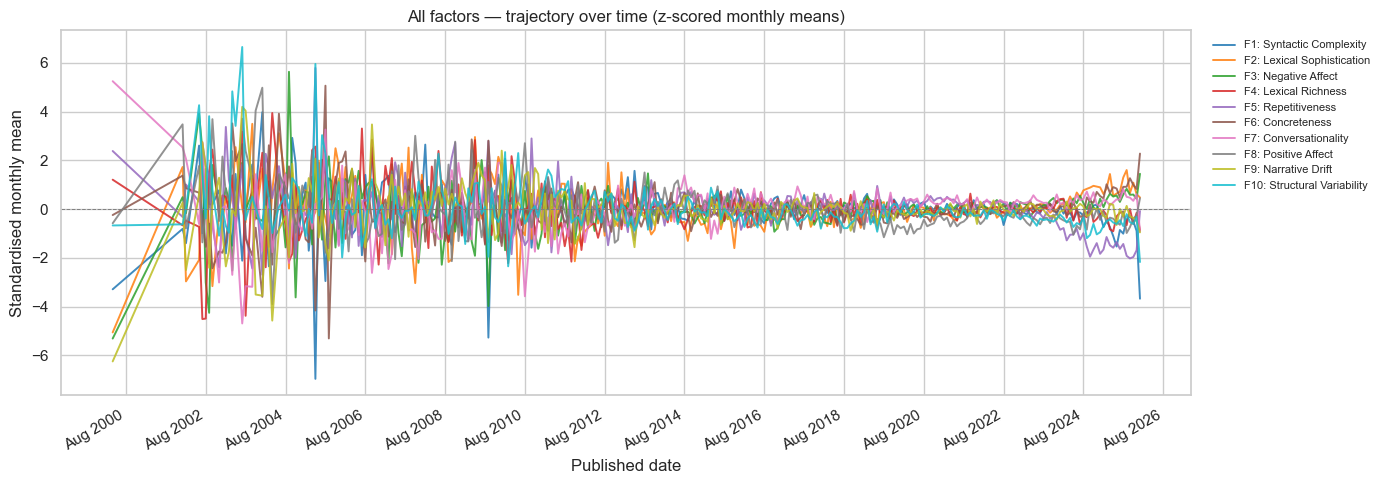

In [88]:
# All factors on one plot (z-scored so they're on the same axis)
monthly_z = (monthly_mean - monthly_mean.mean()) / monthly_mean.std()

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', n_colors=len(FACTOR_COLS))

for i, f in enumerate(FACTOR_COLS):
    ax.plot(dates, monthly_z[f], label=f'{f}: {FACTOR_NAMES[f]}',
            color=palette[i], linewidth=1.4, alpha=0.85)

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.set_ylabel('Standardised monthly mean')
ax.set_xlabel('Published date')
ax.set_title('All factors — trajectory over time (z-scored monthly means)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_trajectory_combined.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Factor scores by rating

Boxplots of factor scores split by AO3 content rating.

In [89]:
# rating is stored as a list-string, e.g. "['Explicit']"
df['rating_clean'] = df['rating'].str.strip("[]").str.replace("'", "", regex=False).str.strip()

RATING_ORDER = ['General Audiences', 'Teen And Up Audiences', 'Mature', 'Explicit', 'Not Rated']
df['rating_clean'] = pd.Categorical(df['rating_clean'], categories=RATING_ORDER, ordered=True)

print(df['rating_clean'].value_counts().sort_index().to_string())

rating_clean
General Audiences        5300
Teen And Up Audiences    5473
Mature                   2097
Explicit                 2551
Not Rated                1545


/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/1350881403.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/1350881403.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/1350881403.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/1350881403.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/135

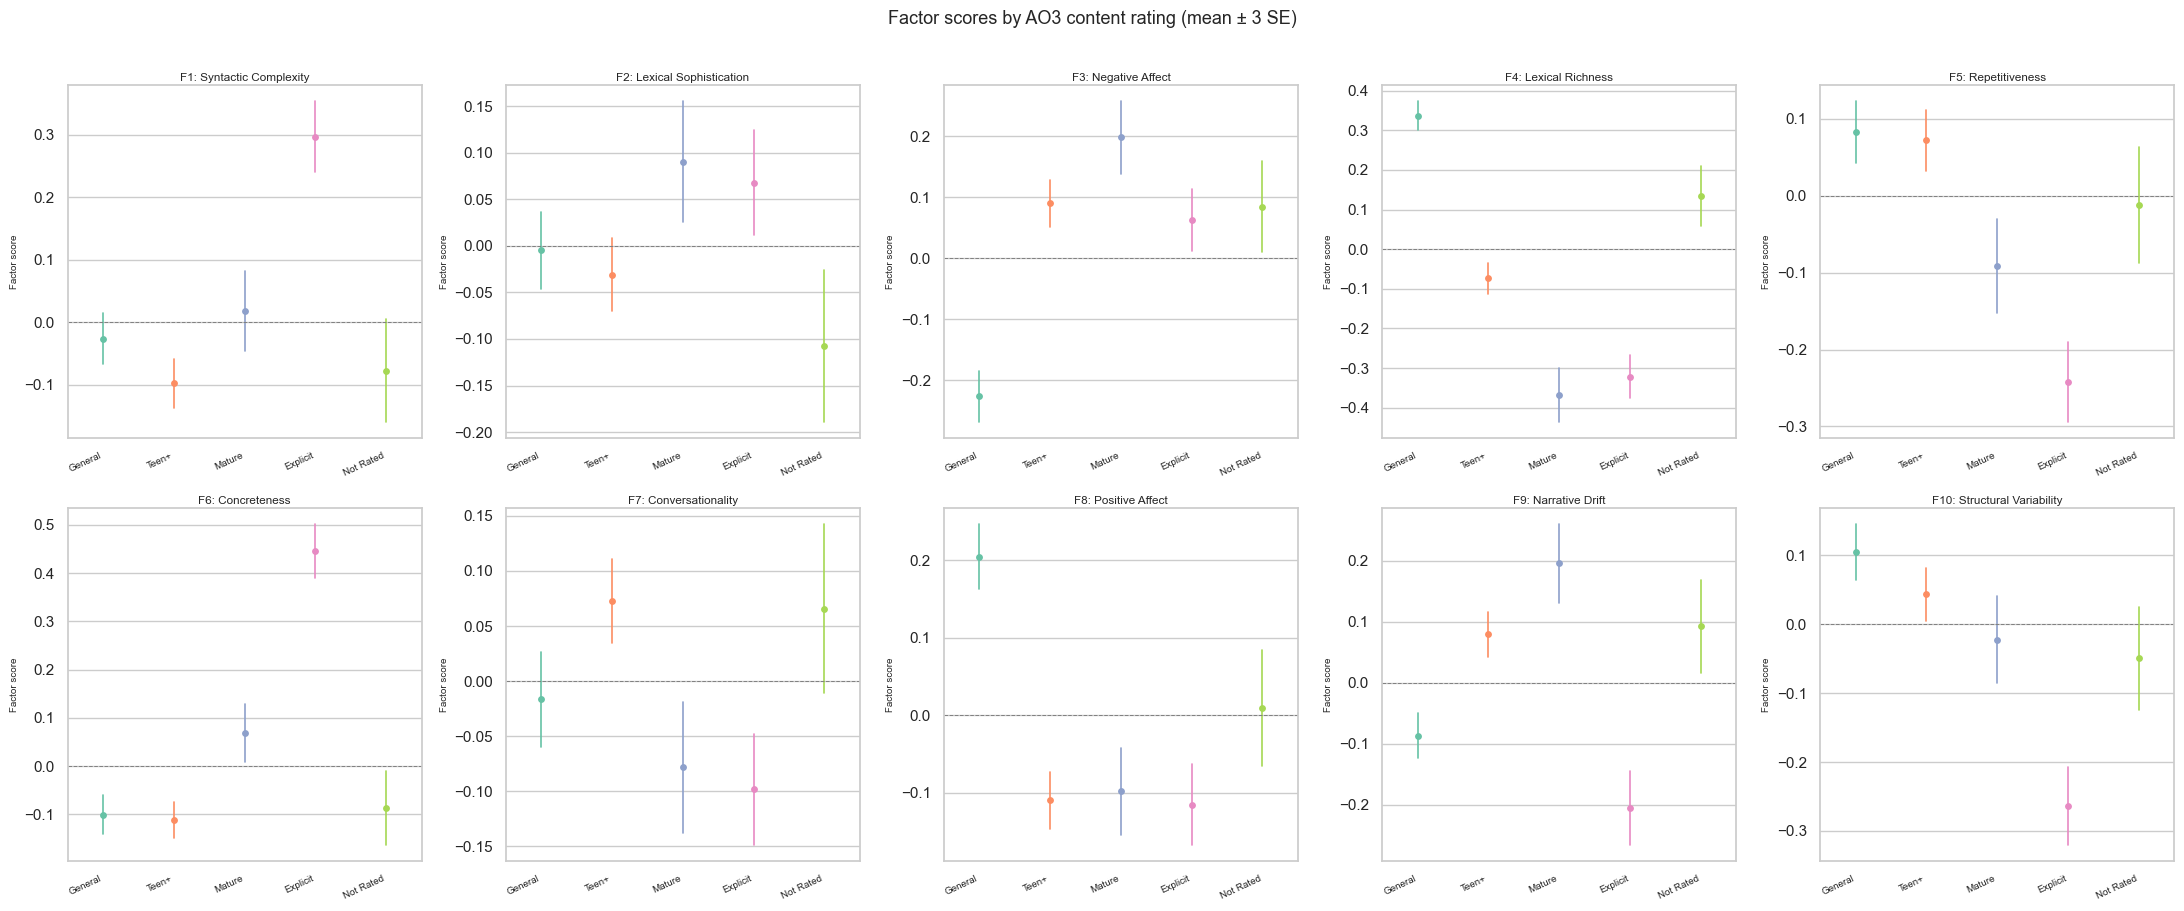

In [90]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharey=False)
axes = axes.flatten()
palette = sns.color_palette('Set2', n_colors=len(RATING_ORDER))

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    sns.pointplot(
        data=df, x='rating_clean', y=f, order=RATING_ORDER,
        palette=palette, hue='rating_clean', legend=False,
        errorbar=('se', 3), ax=ax, markersize=4, linewidth=1.2
    )
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.set_xlabel('')
    ax.set_ylabel('Factor score', fontsize=7)
    ax.set_xticklabels(
        ['General', 'Teen+', 'Mature', 'Explicit', 'Not Rated'],
        fontsize=7, rotation=25, ha='right'
    )

plt.suptitle('Factor scores by AO3 content rating (mean ± 3 SE)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_by_rating.png', dpi=300, bbox_inches='tight')
plt.show()

### Radar profile

Each rating's full factor "signature" as a radar/spider chart. Radii are shared across all 5 panels for fair comparison; the dashed circle marks the population mean (0) for every factor — bulging outside it means above-average, pulled inside means below-average.

                          F1     F2     F3     F4     F5     F6     F7     F8  \
rating_clean                                                                    
General Audiences     -0.026 -0.005 -0.227  0.337  0.082 -0.101 -0.016  0.205   
Teen And Up Audiences -0.098 -0.031  0.090 -0.073  0.072 -0.112  0.073 -0.110   
Mature                 0.018  0.090  0.198 -0.368 -0.092  0.068 -0.078 -0.098   
Explicit               0.297  0.068  0.063 -0.321 -0.242  0.446 -0.098 -0.115   
Not Rated             -0.078 -0.107  0.085  0.134 -0.012 -0.088  0.066  0.009   

                          F9    F10  
rating_clean                         
General Audiences     -0.087  0.105  
Teen And Up Audiences  0.079  0.044  
Mature                 0.196 -0.022  
Explicit              -0.206 -0.264  
Not Rated              0.092 -0.049  


/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/914265153.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


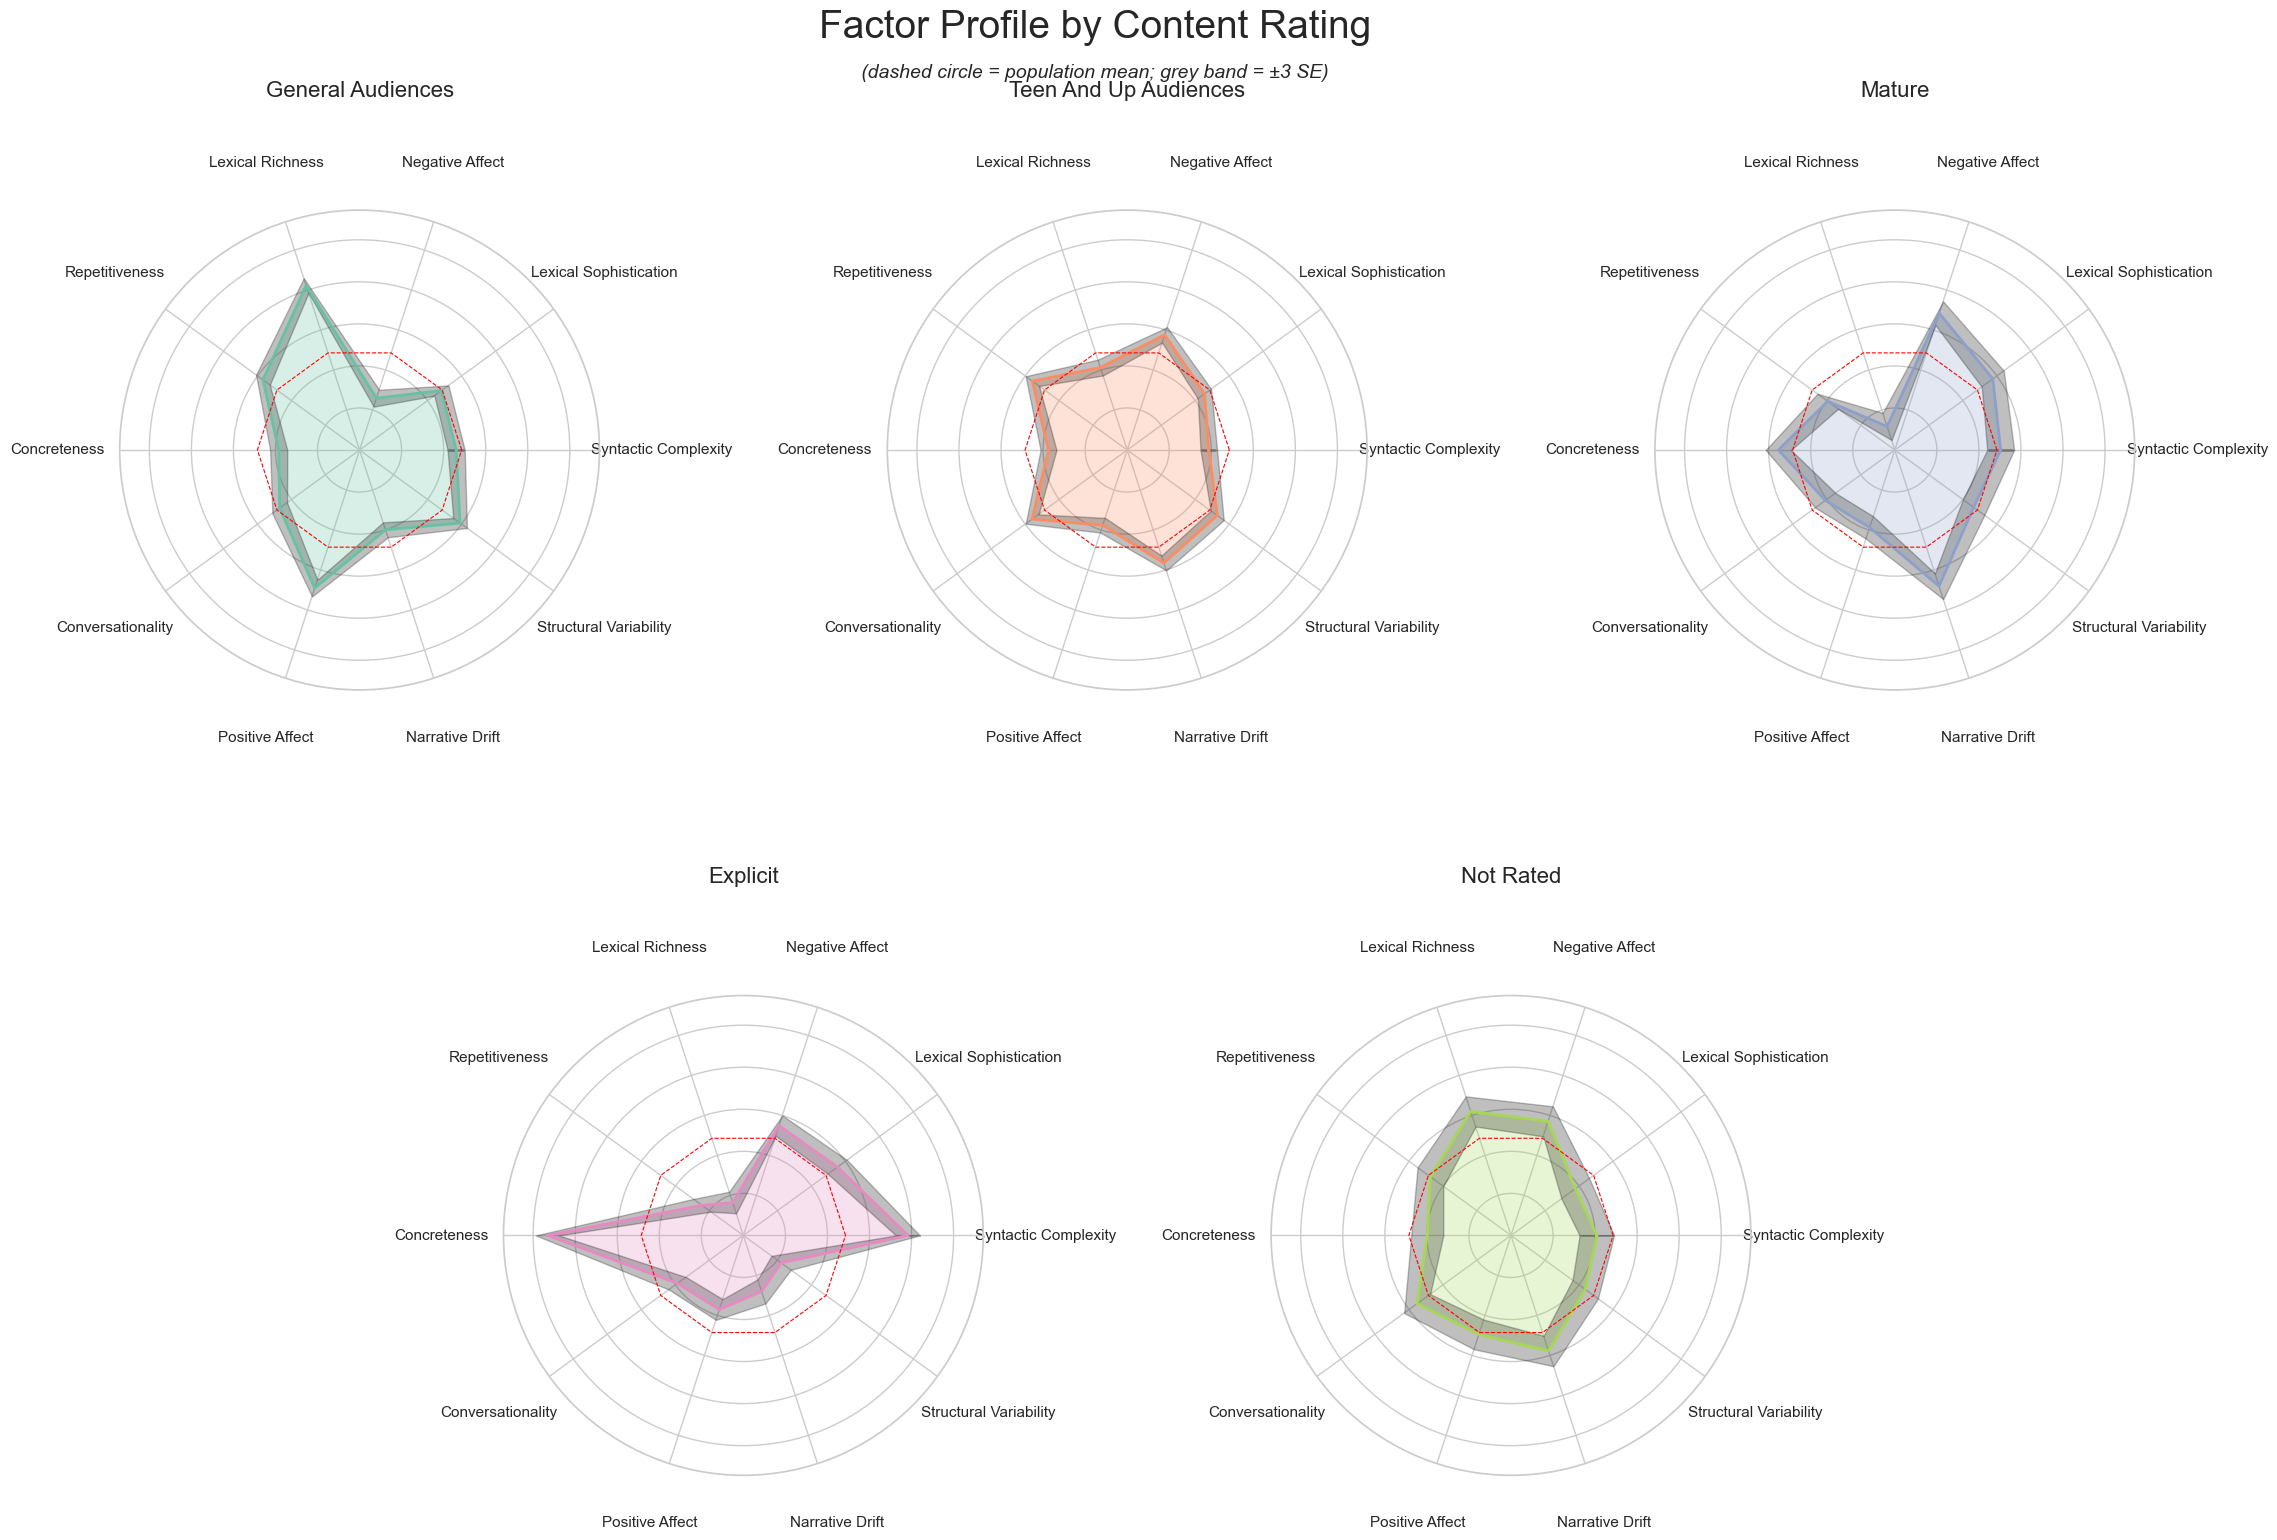

In [91]:
rating_means = df.groupby('rating_clean', observed=True)[FACTOR_COLS].mean()
rating_err   = df.groupby('rating_clean', observed=True)[FACTOR_COLS].sem() * 3  # 3 SE, matching the pointplot convention
print(rating_means.round(3))

labels  = [FACTOR_NAMES[f] for f in FACTOR_COLS]
n_vars  = len(FACTOR_COLS)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

# Polar axes don't handle negative radii the way a z-score radar chart needs
# (negative r flips to the opposite angle), so shift everything non-negative.
# The dashed circle drawn at r=offset marks where the true zero (population mean) sits.
offset = -(rating_means.values - rating_err.values).min() + 0.05
r_data = (rating_means.values + rating_err.values).max() + offset + 0.05
r_max  = r_data * 1.1

fig = plt.figure(figsize=(26, 17))
gs  = fig.add_gridspec(2, 6, hspace=0.5, wspace=3)
grid_positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]
axes = [fig.add_subplot(pos, projection='polar') for pos in grid_positions]

palette = sns.color_palette('Set2', n_colors=len(RATING_ORDER))

for i, rating in enumerate(RATING_ORDER):
    ax = axes[i]
    mean_vals = (rating_means.loc[rating, FACTOR_COLS] + offset).tolist()
    err_vals  = rating_err.loc[rating, FACTOR_COLS].tolist()
    mean_vals += mean_vals[:1]
    err_vals  += err_vals[:1]
    lower = [m - e for m, e in zip(mean_vals, err_vals)]
    upper = [m + e for m, e in zip(mean_vals, err_vals)]

    ax.fill(angles, mean_vals, color=palette[i], alpha=0.25)          # main colored fill
    ax.plot(angles, mean_vals, color=palette[i], linewidth=2)
    ax.fill_between(angles, lower, upper, color='black', alpha=0.25)  # grey/black ±3 SE band on top
    ax.plot(angles, [offset] * len(angles), color='red', linewidth=0.8, linestyle='--')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11, fontweight='medium')
    ax.set_ylim(0, r_max)
    ax.set_yticklabels([])
    ax.set_title(rating, fontsize=16, pad=42)
    ax.tick_params(axis='x', pad=32)

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.suptitle('Factor Profile by Content Rating', y=0.985, fontsize=28)
fig.text(0.5, 0.945, '(dashed circle = population mean; grey band = ±3 SE)', ha='center', fontsize=14, style='italic')
plt.savefig(VIS_DIR / 'rating_radar_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistical test: does the profile actually differ?

The radar chart shows visual separation, but two complementary tests confirm whether it's real:

- **PERMANOVA** — tests whether the mean 10-factor profile (the shape/position of the radar chart) differs across groups. Permutation-based (999 label shuffles), so it makes no multivariate-normality assumption.
- **Multivariate dispersion test** — the 10-dimensional generalization of the median + absolute-deviation logic used throughout the rest of this project: each text's Euclidean distance to its own group's coordinate-wise median, compared across groups via Kruskal-Wallis. Tests whether the *spread* of the profile differs, not just its centre — check this alongside PERMANOVA, since a significant PERMANOVA result can be driven by dispersion differences rather than a genuine difference in mean profile.

Both are defined here and reused for the fandom breakdown below.

=== Rating: does the 10-factor profile differ? ===
PERMANOVA   (profile MEAN differs?):   F=102.90  R2=0.0237  p=0.0010  (999 permutations)
Dispersion  (profile SPREAD differs?): H=190.75  p=0.0000  (Kruskal-Wallis)


/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/784965571.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['rating_clean'], y=rating_dist, order=RATING_ORDER, palette=palette, ax=ax)


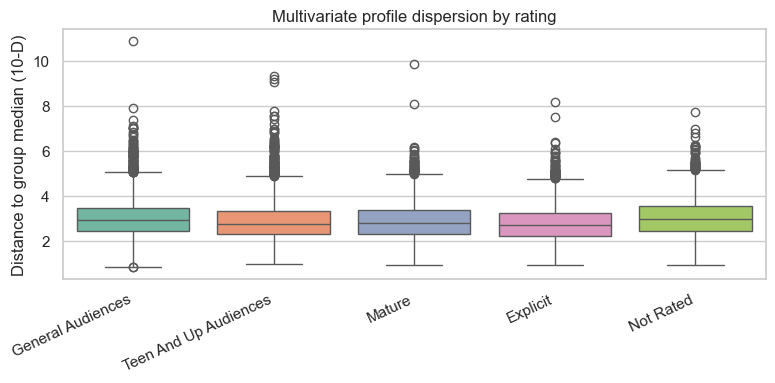

In [92]:
def permanova(X, groups, n_perm=999, seed=2001):
    """One-way PERMANOVA via centroid sum-of-squares (exact for Euclidean
    distance, avoids building an O(n^2) distance matrix). Tests whether
    group centroids (mean profile) differ. Returns observed F, R2, and a
    permutation p-value."""
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    groups = np.asarray(groups)
    levels = np.unique(groups)
    n, k = X.shape[0], len(levels)

    def f_stat(g):
        grand = X.mean(axis=0)
        ss_t = ((X - grand) ** 2).sum()
        ss_w = sum(((X[g == lvl] - X[g == lvl].mean(axis=0)) ** 2).sum() for lvl in levels)
        ss_a = ss_t - ss_w
        return (ss_a / (k - 1)) / (ss_w / (n - k)), ss_a / ss_t

    f_obs, r2 = f_stat(groups)
    f_perm = np.array([f_stat(rng.permutation(groups))[0] for _ in range(n_perm)])
    p = (np.sum(f_perm >= f_obs) + 1) / (n_perm + 1)
    return {'F': f_obs, 'R2': r2, 'p': p, 'n_perm': n_perm}


def multivariate_dispersion_test(X, groups):
    """Multivariate generalisation of Levene's test, kept consistent with
    this project's median + absolute-deviation logic elsewhere: each point's
    distance to its OWN group's coordinate-wise median, then Kruskal-Wallis
    across groups on those distances. Significant = groups differ in the
    SPREAD of their overall profile, not just its centre -- check this
    alongside PERMANOVA, since profile-mean and dispersion differences can
    otherwise be confounded."""
    X = np.asarray(X, dtype=float)
    groups = np.asarray(groups)
    dist = np.empty(len(X))
    for lvl in np.unique(groups):
        mask = groups == lvl
        med = np.median(X[mask], axis=0)
        dist[mask] = np.sqrt(((X[mask] - med) ** 2).sum(axis=1))
    h, p = stats.kruskal(*[dist[groups == lvl] for lvl in np.unique(groups)])
    return {'H': h, 'p': p}, dist


def report_profile_tests(name, X, groups, n_perm=999):
    perm = permanova(X, groups, n_perm=n_perm)
    disp, dist = multivariate_dispersion_test(X, groups)
    print(f"=== {name}: does the 10-factor profile differ? ===")
    print(f"PERMANOVA   (profile MEAN differs?):   F={perm['F']:.2f}  R2={perm['R2']:.4f}  p={perm['p']:.4f}  ({perm['n_perm']} permutations)")
    print(f"Dispersion  (profile SPREAD differs?): H={disp['H']:.2f}  p={disp['p']:.4f}  (Kruskal-Wallis)")
    return perm, disp, dist


X_all = df[FACTOR_COLS].to_numpy()
rating_perm, rating_disp, rating_dist = report_profile_tests('Rating', X_all, df['rating_clean'].to_numpy())

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df['rating_clean'], y=rating_dist, order=RATING_ORDER, palette=palette, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Distance to group median (10-D)')
ax.set_title('Multivariate profile dispersion by rating')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(VIS_DIR / 'rating_profile_dispersion.png', dpi=300, bbox_inches='tight')
plt.show()

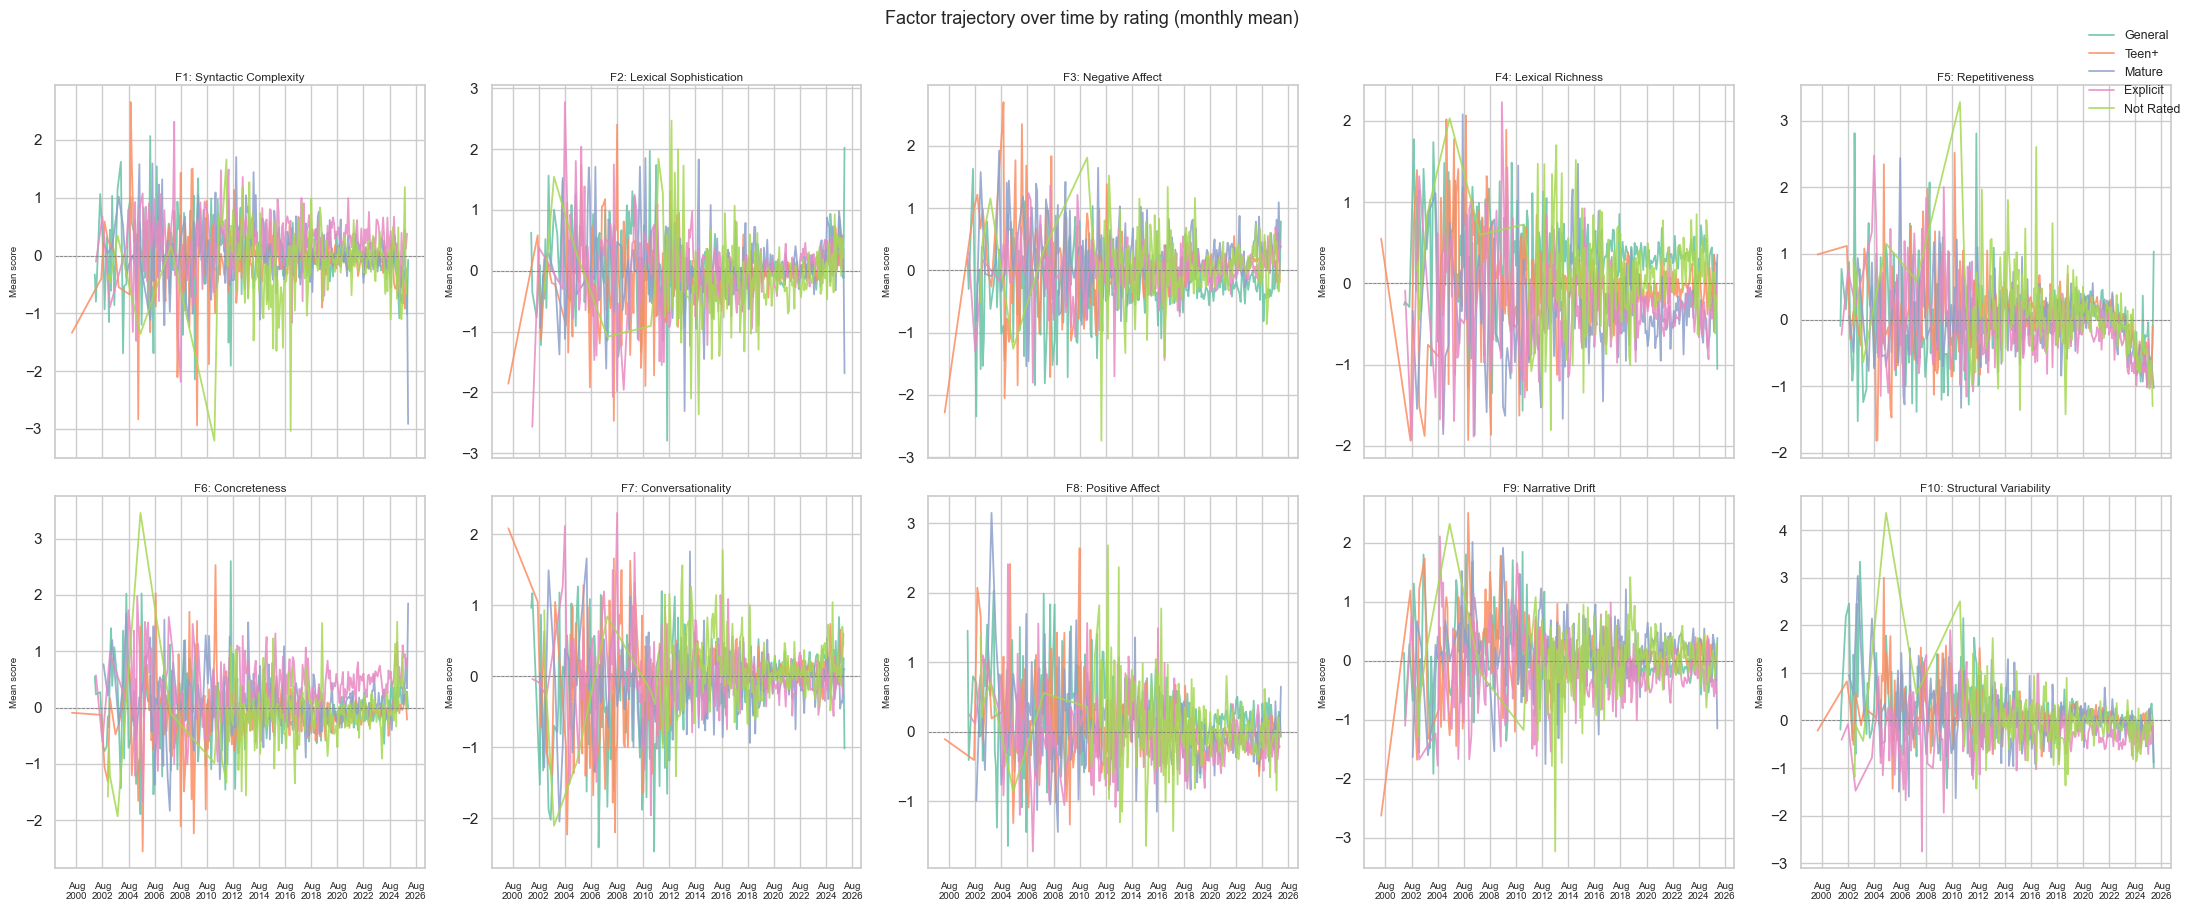

In [93]:
# Trajectory over time faceted by rating — one subplot per factor
rating_monthly = (
    df.groupby(['year_month', 'rating_clean'], observed=True)[FACTOR_COLS]
    .mean()
    .reset_index()
)
rating_monthly['date'] = rating_monthly['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharex=True)
axes = axes.flatten()
pal = dict(zip(RATING_ORDER, sns.color_palette('Set2', n_colors=len(RATING_ORDER))))

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    for rating in RATING_ORDER:
        sub = rating_monthly[rating_monthly['rating_clean'] == rating]
        ax.plot(sub['date'], sub[f], label=rating, color=pal[rating],
                linewidth=1.3, alpha=0.85)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
    ax.tick_params(axis='x', labelsize=7)
    ax.set_ylabel('Mean score', fontsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['General', 'Teen+', 'Mature', 'Explicit', 'Not Rated'],
           loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9, frameon=False)

plt.suptitle('Factor trajectory over time by rating (monthly mean)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_trajectory_by_rating.png', dpi=300, bbox_inches='tight')
plt.show()

### Trajectory on a common developmental axis (min-max normalized time)

Rating doesn't have the acute non-overlap problem fandom does (all five ratings are used throughout the whole corpus timeframe), but the same `published_norm`-style construction is still worth using here for consistency: it normalizes `published` to [0, 1] **within each text's own fandom** before aggregating by rating, so a rating's trajectory reflects "how it trends across a typical fandom's lifecycle" rather than being confounded by which fandoms happen to dominate which calendar years (e.g. `random` is exclusively recent calendar dates — a raw-date rating trend could partly just reflect `random`'s growing share of the corpus over time, not a real within-fandom rating effect).

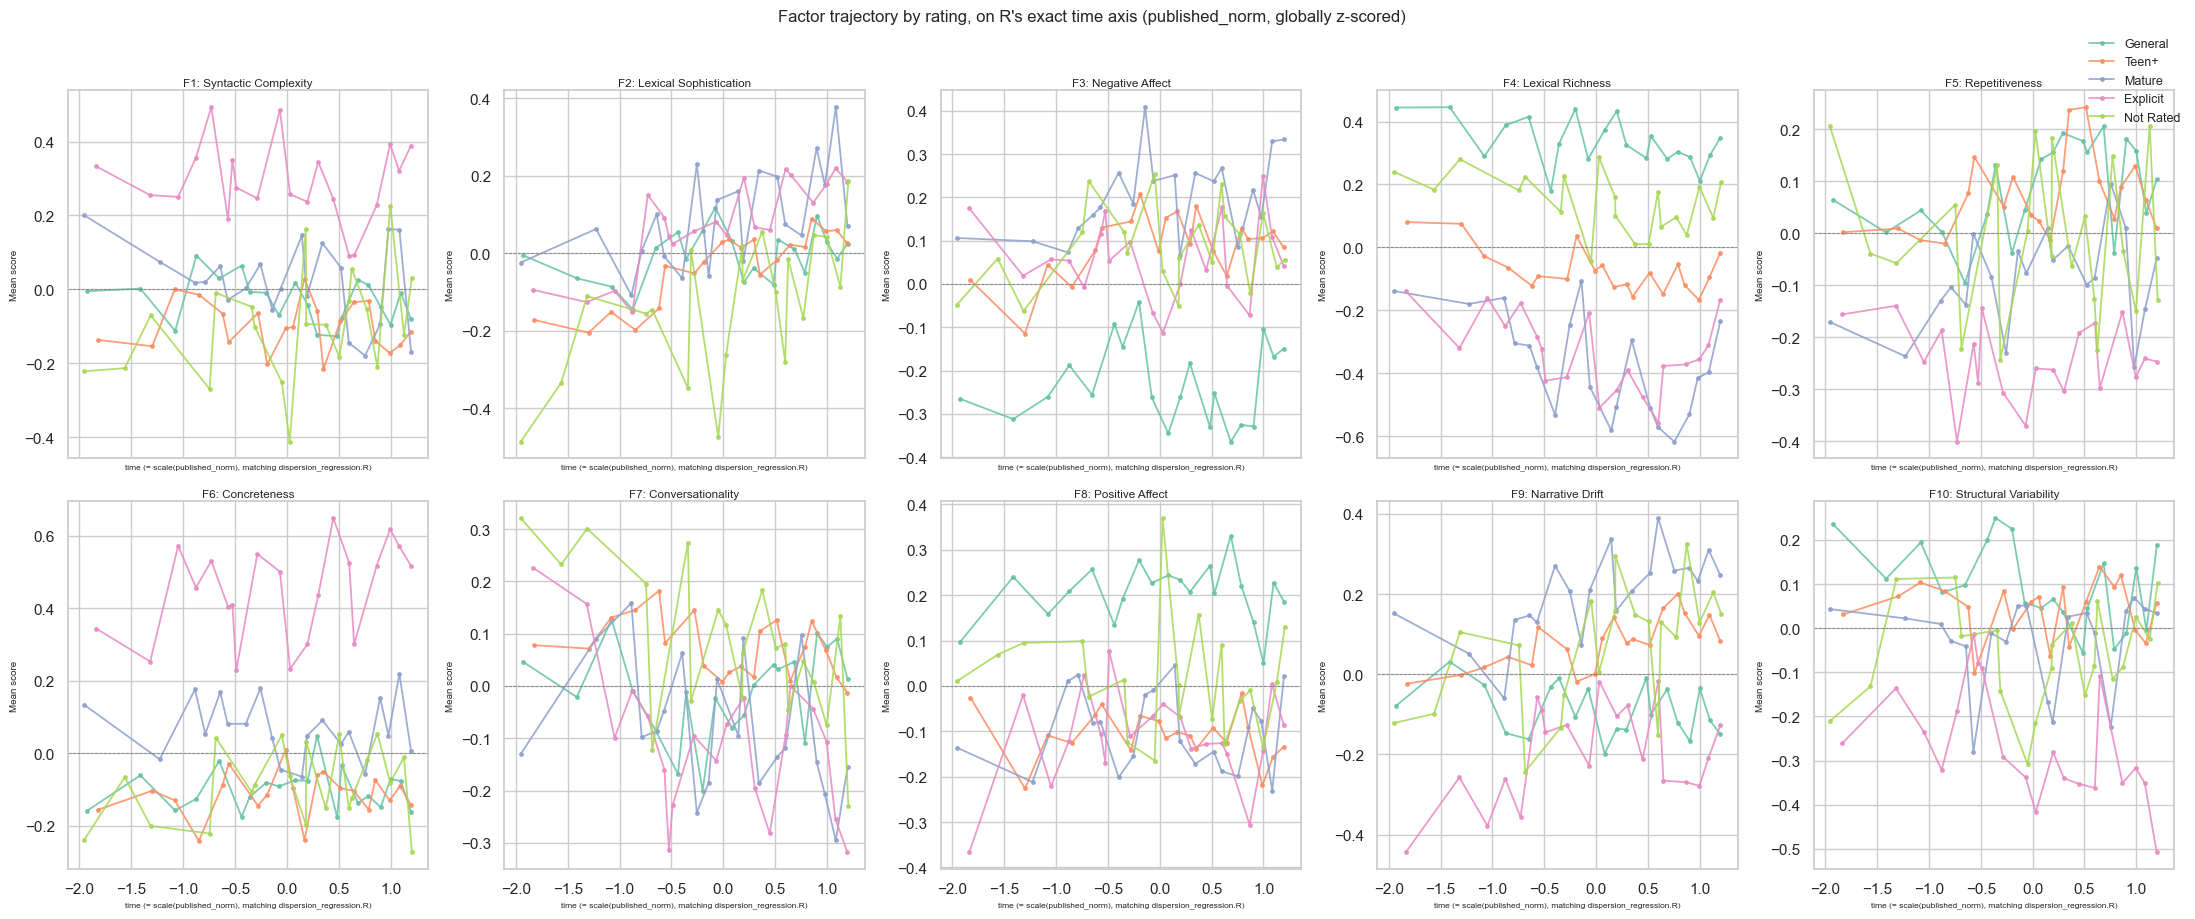

In [94]:
N_BINS = 20

# exact match to dispersion_regression.R (see fandom section above for the
# verification that global z-scoring doesn't dilute per-fandom patterns)
df['published_num'] = df['published'].astype('int64')
df['published_norm'] = df.groupby('fandom_label', observed=True)['published_num'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
df['time'] = (df['published_norm'] - df['published_norm'].mean()) / df['published_norm'].std()

df['time_pctile'] = df.groupby('fandom_label', observed=True)['time'].rank(pct=True)
df['time_bin'] = (df['time_pctile'] * N_BINS).clip(upper=N_BINS - 1e-9).astype(int)

rating_time_binned = (
    df.groupby(['rating_clean', 'time_bin'], observed=True)
    .agg(time_mid=('time', 'mean'),
         n=(FACTOR_COLS[0], 'count'),
         **{f: (f, 'mean') for f in FACTOR_COLS})
    .reset_index()
)

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharex=True)
axes = axes.flatten()
pal = dict(zip(RATING_ORDER, sns.color_palette('Set2', n_colors=len(RATING_ORDER))))

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    for rating in RATING_ORDER:
        sub = rating_time_binned[rating_time_binned['rating_clean'] == rating].sort_values('time_mid')
        ax.plot(sub['time_mid'], sub[f], label=rating, color=pal[rating],
                linewidth=1.3, alpha=0.85, marker='o', markersize=2.5)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.set_xlabel("time (= scale(published_norm), matching dispersion_regression.R)", fontsize=6)
    ax.set_ylabel('Mean score', fontsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['General', 'Teen+', 'Mature', 'Explicit', 'Not Rated'],
           loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9, frameon=False)

plt.suptitle("Factor trajectory by rating, on R's exact time axis (published_norm, globally z-scored)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_trajectory_by_rating_normtime.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Factor scores by fandom

Same breakdown as Section 5, grouped by `fandom_label` (5 specific fandoms from the chr27 subset, plus `random` — the general human sample) instead of content rating.

**Caveat for the trajectory panel below:** `random` only covers 2022-12 to 2026-01, while HP/LOTR/MAG/PJ/RPF span 2000-2024 and mostly stop before 2024 — there's almost no date overlap between `random` and the other five. Treat any apparent "trend" involving `random` there as an artifact of non-overlapping time windows, not a real signal.

In [95]:
FANDOM_ORDER   = ['HP', 'LOTR', 'MAG', 'PJ', 'RPF', 'random']
FANDOM_DISPLAY = {'HP': 'HP', 'LOTR': 'LOTR', 'MAG': 'MAG', 'PJ': 'PJ', 'RPF': 'RPF', 'random': 'Random'}

df['fandom_label'] = pd.Categorical(df['fandom_label'], categories=FANDOM_ORDER, ordered=True)

print(df['fandom_label'].value_counts().sort_index().to_string())

fandom_label
HP        2974
LOTR      2973
MAG       2972
PJ        2977
RPF       2609
random    2461


/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/3857642063.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER], fontsize=7, rotation=25, ha='right')
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/3857642063.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER], fontsize=7, rotation=25, ha='right')
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/3857642063.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER], fontsize=7, rotation=25, ha='right')
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel

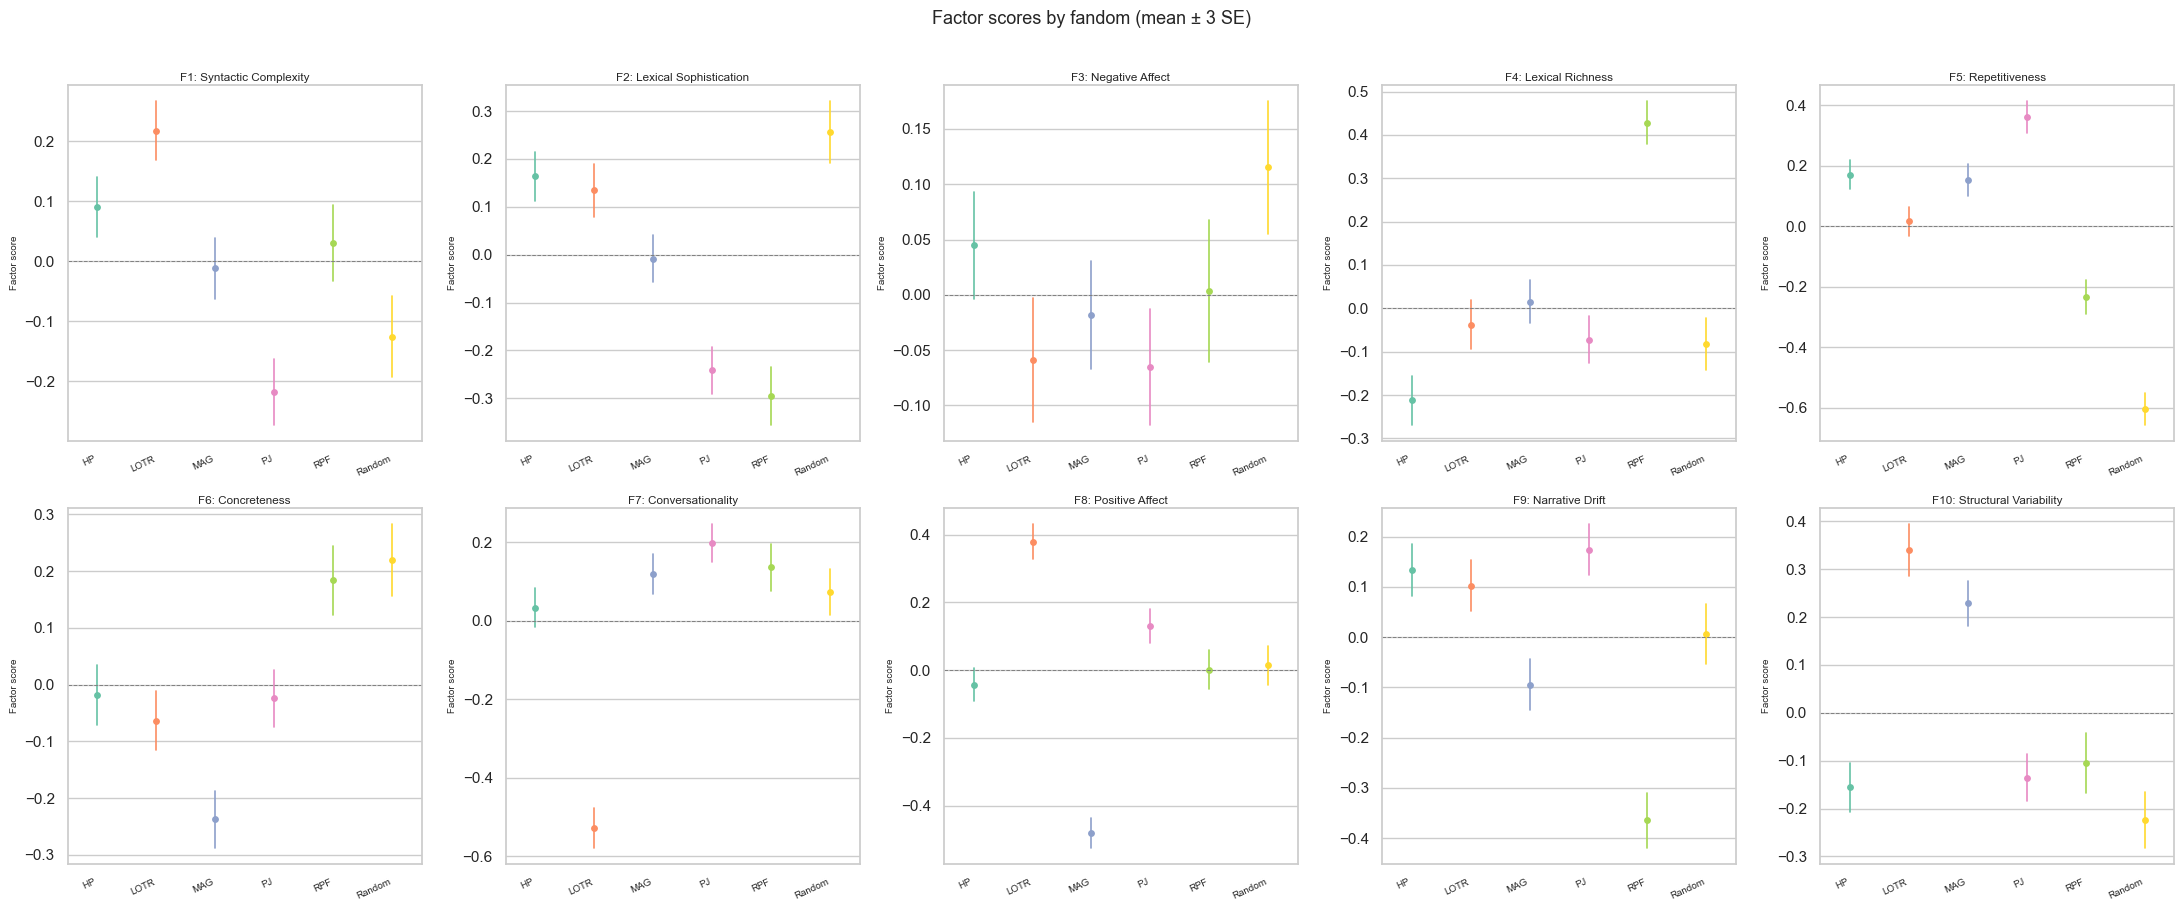

In [96]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharey=False)
axes = axes.flatten()
palette = sns.color_palette('Set2', n_colors=len(FANDOM_ORDER))

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    sns.pointplot(
        data=df, x='fandom_label', y=f, order=FANDOM_ORDER,
        palette=palette, hue='fandom_label', legend=False,
        errorbar=('se', 3), ax=ax, markersize=4, linewidth=1.2
    )
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.set_xlabel('')
    ax.set_ylabel('Factor score', fontsize=7)
    ax.set_xticklabels([FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER], fontsize=7, rotation=25, ha='right')

plt.suptitle('Factor scores by fandom (mean ± 3 SE)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_by_fandom.png', dpi=300, bbox_inches='tight')
plt.show()

### Radar profile

Each fandom's full factor "signature" as a radar/spider chart. Radii are shared across all 6 panels for fair comparison; the dashed circle marks the population mean (0) for every factor.

                 F1     F2     F3     F4     F5     F6     F7     F8     F9  \
fandom_label                                                                  
HP            0.091  0.164  0.045 -0.212  0.171 -0.018  0.032 -0.042  0.133   
LOTR          0.218  0.134 -0.059 -0.037  0.017 -0.064 -0.529  0.380  0.102   
MAG          -0.012 -0.009 -0.019  0.016  0.154 -0.237  0.119 -0.480 -0.095   
PJ           -0.218 -0.242 -0.065 -0.072  0.362 -0.024  0.197  0.130  0.174   
RPF           0.030 -0.295  0.003  0.428 -0.233  0.184  0.136  0.002 -0.364   
random       -0.126  0.256  0.115 -0.083 -0.604  0.220  0.073  0.014  0.006   

                F10  
fandom_label         
HP           -0.156  
LOTR          0.340  
MAG           0.229  
PJ           -0.136  
RPF          -0.104  
random       -0.224  


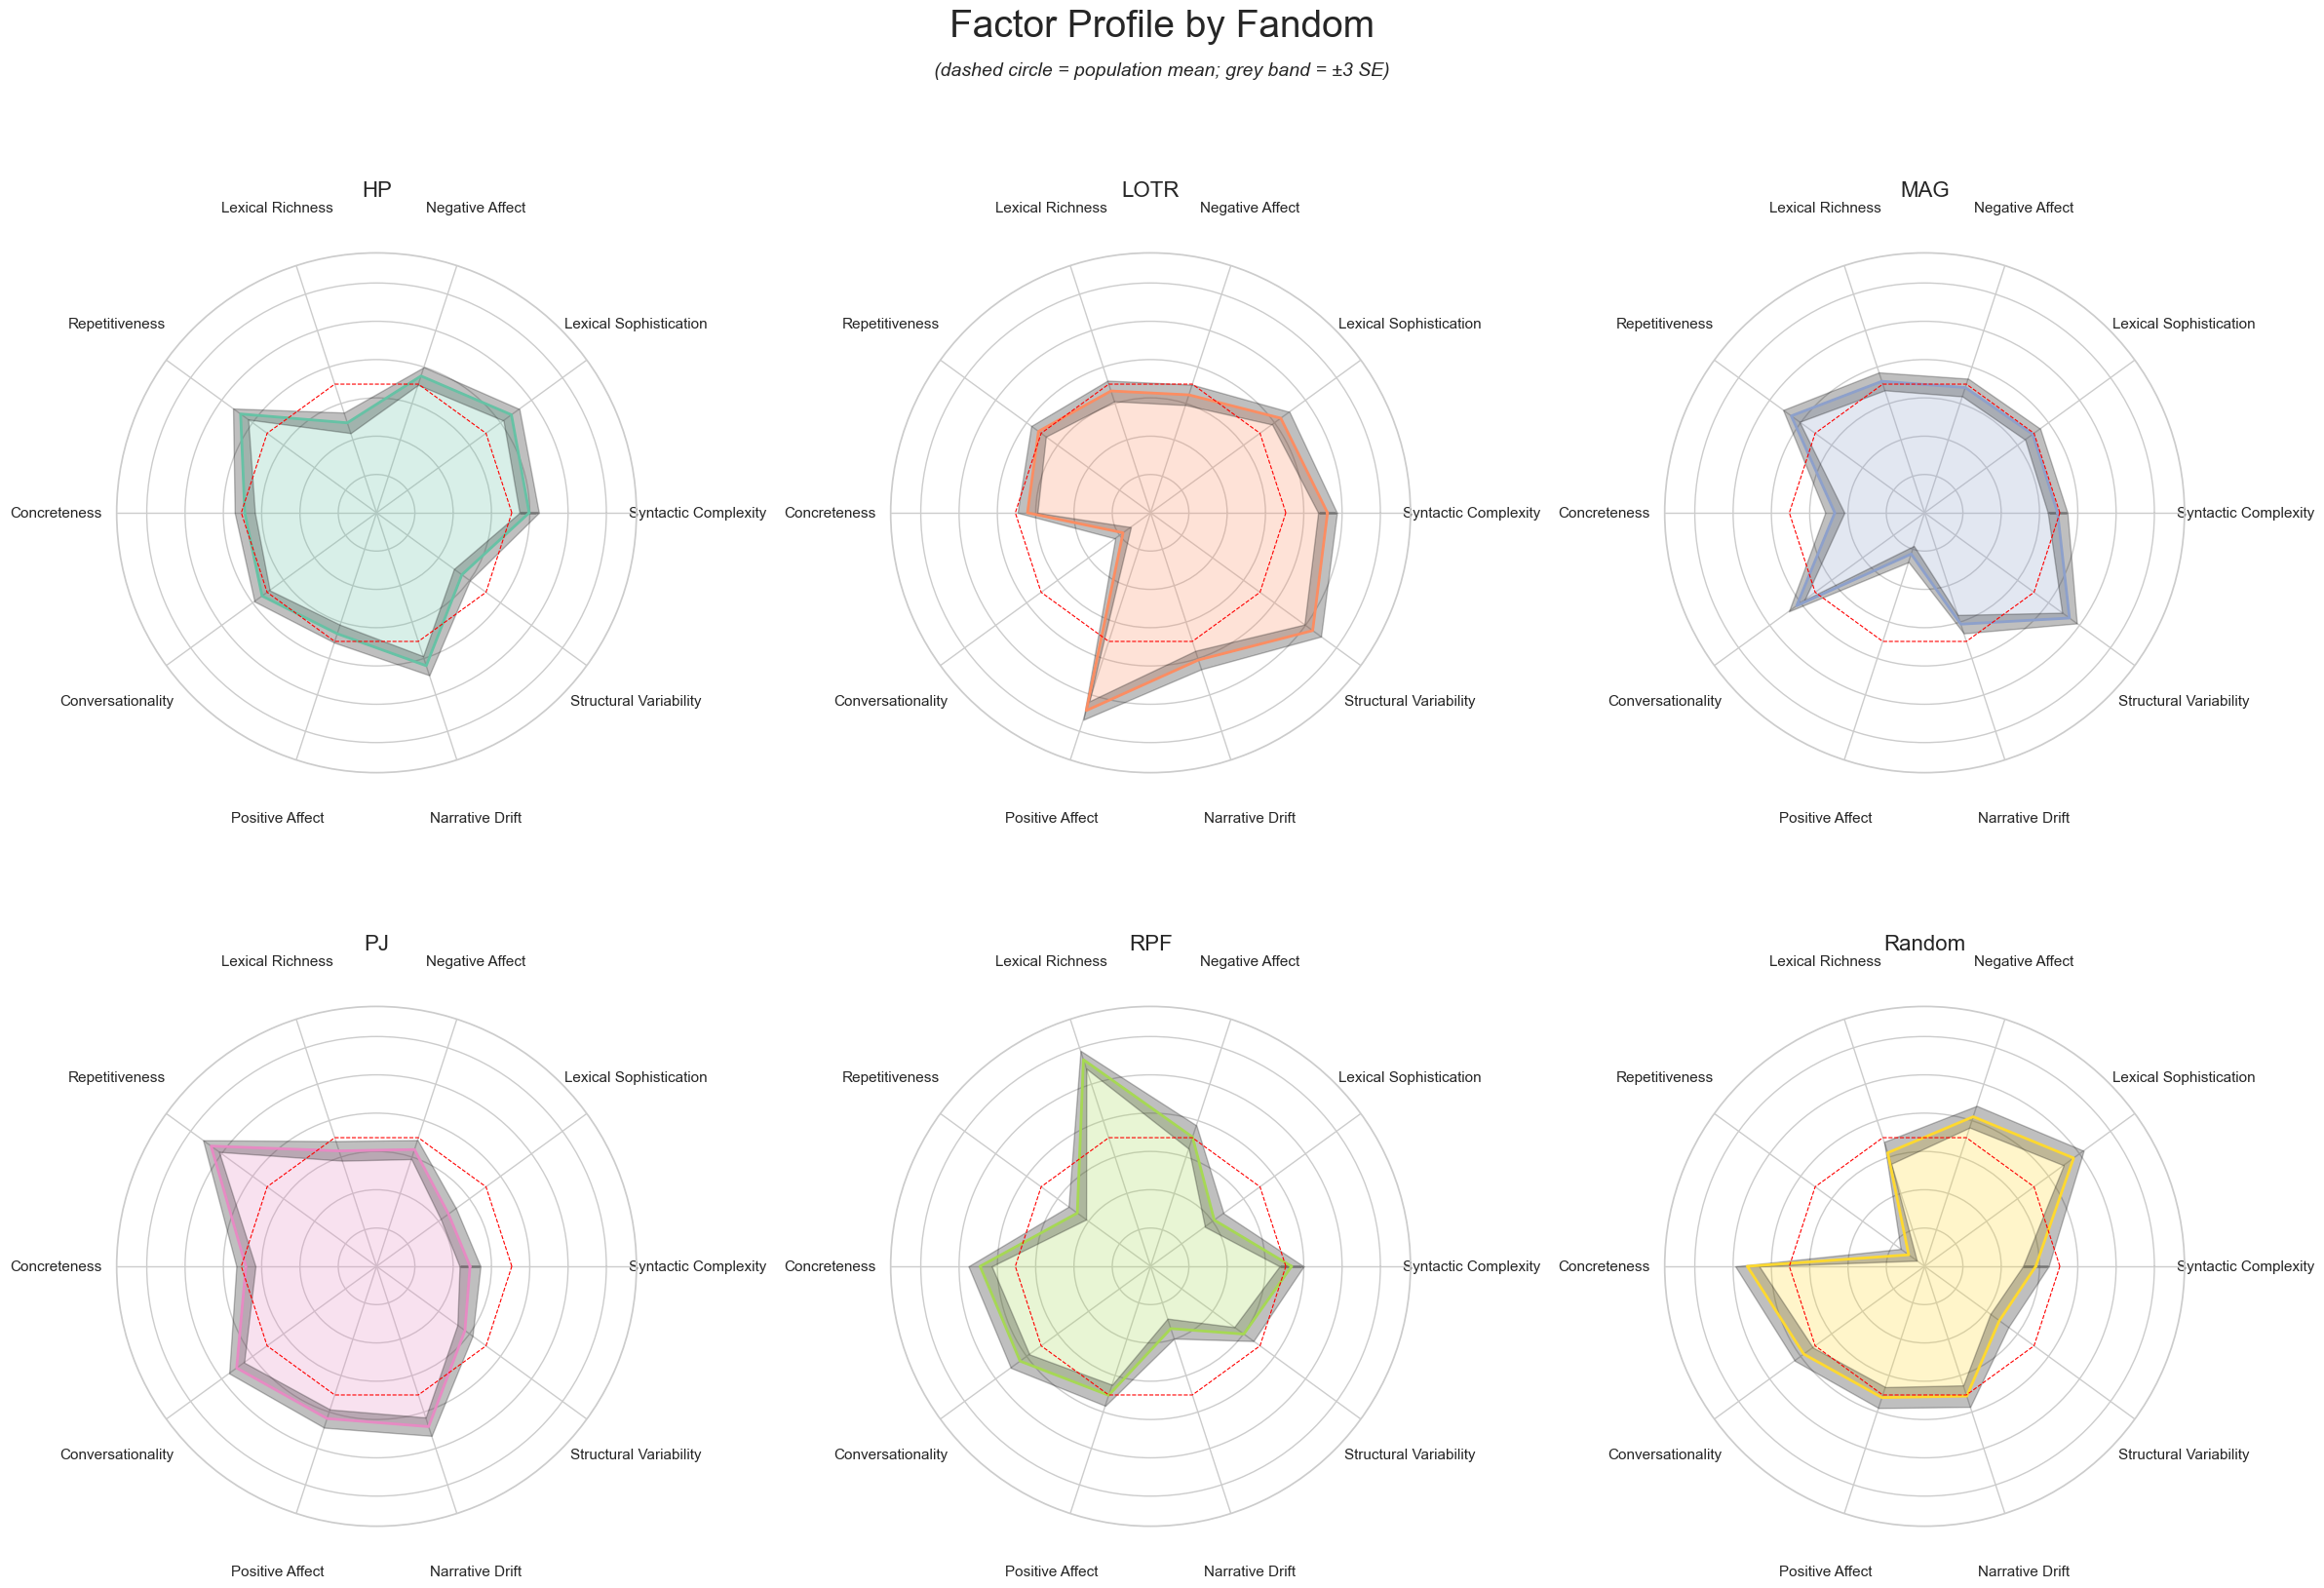

In [97]:
fandom_means = df.groupby('fandom_label', observed=True)[FACTOR_COLS].mean()
fandom_err   = df.groupby('fandom_label', observed=True)[FACTOR_COLS].sem() * 3  # 3 SE, matching the pointplot convention
print(fandom_means.round(3))

labels  = [FACTOR_NAMES[f] for f in FACTOR_COLS]
n_vars  = len(FACTOR_COLS)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

# Polar axes don't handle negative radii the way a z-score radar chart needs
# (negative r flips to the opposite angle), so shift everything non-negative.
# The dashed circle drawn at r=offset marks where the true zero (population mean) sits.
offset = -(fandom_means.values - fandom_err.values).min() + 0.05
r_data = (fandom_means.values + fandom_err.values).max() + offset + 0.05
r_max  = r_data * 1.1

fig, axes = plt.subplots(2, 3, figsize=(24, 17), subplot_kw=dict(polar=True))
axes = axes.flatten()
palette = sns.color_palette('Set2', n_colors=len(FANDOM_ORDER))

for i, fandom in enumerate(FANDOM_ORDER):
    ax = axes[i]
    mean_vals = (fandom_means.loc[fandom, FACTOR_COLS] + offset).tolist()
    err_vals  = fandom_err.loc[fandom, FACTOR_COLS].tolist()
    mean_vals += mean_vals[:1]
    err_vals  += err_vals[:1]
    lower = [m - e for m, e in zip(mean_vals, err_vals)]
    upper = [m + e for m, e in zip(mean_vals, err_vals)]

    ax.fill(angles, mean_vals, color=palette[i], alpha=0.25)          # main colored fill
    ax.plot(angles, mean_vals, color=palette[i], linewidth=2)
    ax.fill_between(angles, lower, upper, color='black', alpha=0.25)  # grey/black ±3 SE band on top
    ax.plot(angles, [offset] * len(angles), color='red', linewidth=0.8, linestyle='--')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11, fontweight='medium')
    ax.set_ylim(0, r_max)
    ax.set_yticklabels([])
    ax.set_title(FANDOM_DISPLAY[fandom], fontsize=16, pad=42)
    ax.tick_params(axis='x', pad=32)

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.suptitle('Factor Profile by Fandom', y=0.985, fontsize=28)
fig.text(0.5, 0.945, '(dashed circle = population mean; grey band = ±3 SE)', ha='center', fontsize=14, style='italic')
plt.savefig(VIS_DIR / 'fandom_radar_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistical test: does the profile actually differ?

Same two tests as the rating section above (`permanova`, `multivariate_dispersion_test` — see there for definitions), now grouping by fandom instead of rating.

=== Fandom: does the 10-factor profile differ? ===
PERMANOVA   (profile MEAN differs?):   F=161.48  R2=0.0454  p=0.0010  (999 permutations)
Dispersion  (profile SPREAD differs?): H=268.82  p=0.0000  (Kruskal-Wallis)


/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/284449951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['fandom_label'], y=fandom_dist, order=FANDOM_ORDER, palette=palette, ax=ax)
/var/folders/9l/qmtpyqrj6_x64qt2sdg0thh00000gn/T/ipykernel_34793/284449951.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER])


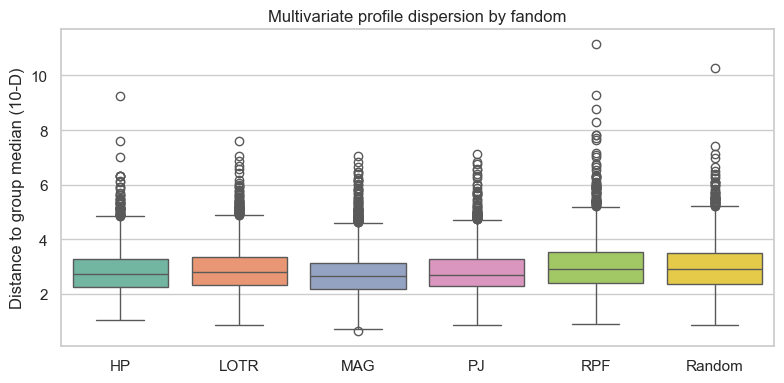

In [98]:
fandom_perm, fandom_disp, fandom_dist = report_profile_tests('Fandom', X_all, df['fandom_label'].to_numpy())

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df['fandom_label'], y=fandom_dist, order=FANDOM_ORDER, palette=palette, ax=ax)
ax.set_xticklabels([FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER])
ax.set_xlabel('')
ax.set_ylabel('Distance to group median (10-D)')
ax.set_title('Multivariate profile dispersion by fandom')
plt.tight_layout()
plt.savefig(VIS_DIR / 'fandom_profile_dispersion.png', dpi=300, bbox_inches='tight')
plt.show()

### Robustness check: adjusted for length and cross-grouping

Two confounds neither test above accounts for, both handled the same way `dispersion_regression.R` handles covariates elsewhere in this project:

- **`logwords`** — text length mechanically affects most of these metrics (F4 is literally a length proxy); not controlling for it lets length differences masquerade as style differences.
- **The other grouping variable** — fandoms likely differ in rating composition and vice versa, so each test could partly be picking up the other's effect rather than its own.

Fix: residualize each factor against `logwords` + the other grouping variable (OLS, same logic as `growth_resid` elsewhere in this project) before re-running both tests on the residuals.

Also worth knowing before trusting the raw rating result specifically: rating's group sizes range from 1,545 to 5,473 (3.5x spread) vs. fandom's 2,461–2,977 (1.2x spread). Combined with the dispersion differences already detected, that imbalance makes PERMANOVA's p-value less trustworthy for rating than for fandom.

In [99]:
def build_design_matrix(df, continuous=None, categorical=None):
    """Intercept + continuous covariates + one-hot (drop-first) categoricals."""
    parts = [pd.Series(1.0, index=df.index, name='intercept')]
    for c in (continuous or []):
        parts.append(df[c].astype(float))
    for c in (categorical or []):
        parts.append(pd.get_dummies(df[c], prefix=c, drop_first=True).astype(float))
    return pd.concat(parts, axis=1).to_numpy()


def residualize_factors(df, factor_cols, continuous=None, categorical=None):
    """OLS-residualize each factor against the given covariates -- same
    logic as growth_resid in dispersion_regression.R, extended to a whole
    factor block at once."""
    X = build_design_matrix(df, continuous, categorical)
    out = np.empty((len(df), len(factor_cols)))
    for j, f in enumerate(factor_cols):
        y = df[f].to_numpy(dtype=float)
        coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        out[:, j] = y - X @ coef
    return out


df['logwords'] = np.log(df['words'])

# fandom, adjusted for logwords + rating composition
X_fandom_adj = residualize_factors(df, FACTOR_COLS, continuous=['logwords'], categorical=['rating_clean'])
fandom_perm_adj, fandom_disp_adj, _ = report_profile_tests(
    'Fandom, adjusted for logwords + rating', X_fandom_adj, df['fandom_label'].to_numpy())

print()

# rating, adjusted for logwords + fandom composition
X_rating_adj = residualize_factors(df, FACTOR_COLS, continuous=['logwords'], categorical=['fandom_label'])
rating_perm_adj, rating_disp_adj, _ = report_profile_tests(
    'Rating, adjusted for logwords + fandom', X_rating_adj, df['rating_clean'].to_numpy())

=== Fandom, adjusted for logwords + rating: does the 10-factor profile differ? ===
PERMANOVA   (profile MEAN differs?):   F=158.50  R2=0.0446  p=0.0010  (999 permutations)
Dispersion  (profile SPREAD differs?): H=500.61  p=0.0000  (Kruskal-Wallis)

=== Rating, adjusted for logwords + fandom: does the 10-factor profile differ? ===
PERMANOVA   (profile MEAN differs?):   F=68.26  R2=0.0158  p=0.0010  (999 permutations)
Dispersion  (profile SPREAD differs?): H=255.31  p=0.0000  (Kruskal-Wallis)


### Pairwise post-hoc: which specific groups differ?

The omnibus tests above only say "somewhere, at least one group differs." For a claim like "MAG differs from HP but not from LOTR," each pair needs its own test. Run on the adjusted (logwords + cross-grouping controlled) profiles from the robustness check above, since that's the more defensible version.

- **Pairwise PERMANOVA** — same test as the omnibus version, restricted to each pair of groups, for the mean profile.
- **Pairwise Mann-Whitney U** on distance-to-group-median — the pairwise analogue of the omnibus Kruskal-Wallis dispersion test.
- Both are **BH-FDR corrected within their family of pairs** (15 fandom pairs, 10 rating pairs) — the same multiple-comparisons logic used earlier in this project, since running many pairwise tests without correction would inflate false positives.

In [100]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests


def pairwise_permanova(X, groups, levels, n_perm=999, seed=2001):
    """Pairwise PERMANOVA for every group pair, BH-FDR corrected within
    the family of pairs."""
    groups = np.asarray(groups)
    rows = []
    for g1, g2 in combinations(levels, 2):
        mask = np.isin(groups, [g1, g2])
        res = permanova(X[mask], groups[mask], n_perm=n_perm, seed=seed)
        rows.append({'group1': g1, 'group2': g2, 'F': res['F'], 'R2': res['R2'], 'p_raw': res['p']})
    out = pd.DataFrame(rows)
    out['p_fdr'] = multipletests(out['p_raw'], method='fdr_bh')[1]
    out['significant'] = out['p_fdr'] < 0.05
    return out.sort_values('p_fdr').reset_index(drop=True)


def pairwise_dispersion(dist, groups, levels):
    """Pairwise Mann-Whitney U on distance-to-group-median (the pairwise
    analogue of the omnibus Kruskal-Wallis dispersion test), BH-FDR
    corrected within the family of pairs."""
    groups = np.asarray(groups)
    rows = []
    for g1, g2 in combinations(levels, 2):
        d1, d2 = dist[groups == g1], dist[groups == g2]
        u, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        rows.append({'group1': g1, 'group2': g2, 'U': u, 'p_raw': p})
    out = pd.DataFrame(rows)
    out['p_fdr'] = multipletests(out['p_raw'], method='fdr_bh')[1]
    out['significant'] = out['p_fdr'] < 0.05
    return out.sort_values('p_fdr').reset_index(drop=True)


# ---- fandom pairwise (on the logwords + rating adjusted profile) ----
fandom_dist_adj = multivariate_dispersion_test(X_fandom_adj, df['fandom_label'].to_numpy())[1]
fandom_pairs_mean = pairwise_permanova(X_fandom_adj, df['fandom_label'].to_numpy(), list(FANDOM_ORDER))
fandom_pairs_disp = pairwise_dispersion(fandom_dist_adj, df['fandom_label'].to_numpy(), list(FANDOM_ORDER))

print(f"=== Fandom pairs, MEAN profile ({fandom_pairs_mean['significant'].sum()}/{len(fandom_pairs_mean)} differ after FDR) ===")
print(fandom_pairs_mean.round(4).to_string(index=False))
print()
print(f"=== Fandom pairs, DISPERSION ({fandom_pairs_disp['significant'].sum()}/{len(fandom_pairs_disp)} differ after FDR) ===")
print(fandom_pairs_disp.round(4).to_string(index=False))

=== Fandom pairs, MEAN profile (15/15 differ after FDR) ===
group1 group2        F     R2  p_raw  p_fdr  significant
    HP   LOTR 140.5955 0.0231  0.001  0.001         True
    HP    MAG  90.0648 0.0149  0.001  0.001         True
    HP     PJ  56.8139 0.0095  0.001  0.001         True
    HP    RPF 121.7833 0.0214  0.001  0.001         True
    HP random 121.8089 0.0219  0.001  0.001         True
  LOTR    MAG 250.5287 0.0405  0.001  0.001         True
  LOTR     PJ 238.3738 0.0385  0.001  0.001         True
  LOTR    RPF 203.3826 0.0352  0.001  0.001         True
  LOTR random 208.3096 0.0369  0.001  0.001         True
   MAG     PJ 149.6215 0.0245  0.001  0.001         True
   MAG    RPF 171.3531 0.0298  0.001  0.001         True
   MAG random 213.4275 0.0378  0.001  0.001         True
    PJ    RPF 133.0483 0.0233  0.001  0.001         True
    PJ random 189.4152 0.0337  0.001  0.001         True
   RPF random  89.8607 0.0174  0.001  0.001         True

=== Fandom pairs, DISPERSIO

In [101]:
# ---- rating pairwise (on the logwords + fandom adjusted profile) ----
rating_dist_adj = multivariate_dispersion_test(X_rating_adj, df['rating_clean'].to_numpy())[1]
rating_pairs_mean = pairwise_permanova(X_rating_adj, df['rating_clean'].to_numpy(), list(RATING_ORDER))
rating_pairs_disp = pairwise_dispersion(rating_dist_adj, df['rating_clean'].to_numpy(), list(RATING_ORDER))

print(f"=== Rating pairs, MEAN profile ({rating_pairs_mean['significant'].sum()}/{len(rating_pairs_mean)} differ after FDR) ===")
print(rating_pairs_mean.round(4).to_string(index=False))
print()
print(f"=== Rating pairs, DISPERSION ({rating_pairs_disp['significant'].sum()}/{len(rating_pairs_disp)} differ after FDR) ===")
print(rating_pairs_disp.round(4).to_string(index=False))

=== Rating pairs, MEAN profile (10/10 differ after FDR) ===
               group1                group2        F     R2  p_raw  p_fdr  significant
    General Audiences Teen And Up Audiences  40.7071 0.0038  0.001 0.0011         True
    General Audiences                Mature  44.8972 0.0060  0.001 0.0011         True
    General Audiences              Explicit 182.0203 0.0227  0.001 0.0011         True
    General Audiences             Not Rated  17.7269 0.0026  0.001 0.0011         True
Teen And Up Audiences                Mature  17.7158 0.0023  0.001 0.0011         True
Teen And Up Audiences              Explicit 179.5399 0.0219  0.001 0.0011         True
               Mature              Explicit  68.3753 0.0145  0.001 0.0011         True
               Mature             Not Rated  11.8009 0.0032  0.001 0.0011         True
             Explicit             Not Rated 100.8757 0.0240  0.001 0.0011         True
Teen And Up Audiences             Not Rated   3.6207 0.0005  0.002 0.0

### Factor by factor: which specific dimensions drive the fandom difference?

PERMANOVA collapses all 10 factors into one joint test, so it can't say whether the fandom effect is driven by one or two factors or spread evenly across all ten. This runs a univariate version of the same logic **per factor**: Kruskal-Wallis (median-based, matching the robust approach used throughout this project) for the omnibus test, and **eta-squared with a bootstrap CI** — the univariate analogue of the R² used above — as the headline number, not the p-value, for the same large-N reason as before. Run on the logwords + rating adjusted profile (`X_fandom_adj`), same as the pairwise section.

=== Fandom, factor by factor -- ranked by eta-squared (effect size), not p-value ===
factor                   name   eta2  eta2_lo95  eta2_hi95 effect_size  p_fdr
    F5         Repetitiveness 0.0939     0.0864     0.1023      medium 0.0000
    F4       Lexical Richness 0.0923     0.0825     0.1037      medium 0.0000
    F8        Positive Affect 0.0708     0.0647     0.0776      medium 0.0000
    F7      Conversationality 0.0669     0.0600     0.0742      medium 0.0000
   F10 Structural Variability 0.0451     0.0394     0.0512       small 0.0000
    F2 Lexical Sophistication 0.0375     0.0321     0.0434       small 0.0000
    F9        Narrative Drift 0.0313     0.0262     0.0373       small 0.0000
    F6           Concreteness 0.0231     0.0189     0.0281       small 0.0000
    F1   Syntactic Complexity 0.0200     0.0161     0.0244       small 0.0000
    F3        Negative Affect 0.0017     0.0009     0.0033  negligible 0.0001


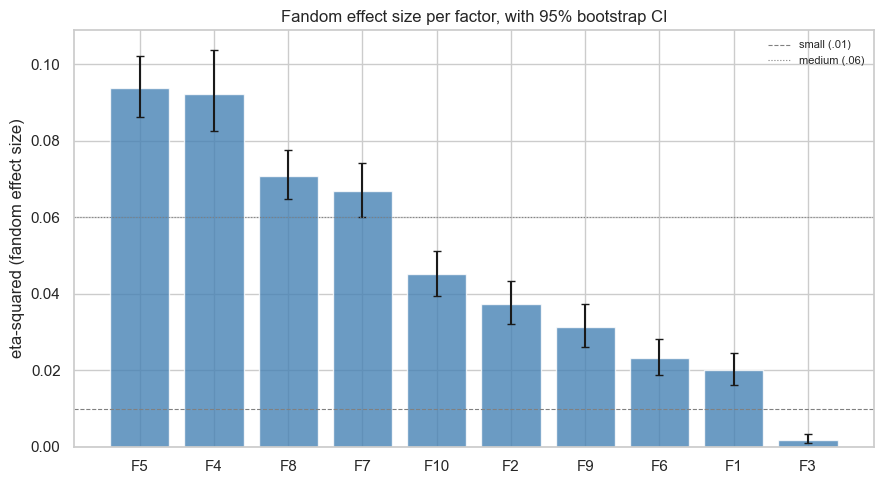

In [102]:
def eta_squared(y, groups):
    """One-way eta-squared: SS_between / SS_total -- the univariate
    analogue of the R2 used for the multivariate PERMANOVA above."""
    y = np.asarray(y, dtype=float)
    groups = np.asarray(groups)
    levels = np.unique(groups)
    grand_mean = y.mean()
    ss_total = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(y[groups == lvl]) * (y[groups == lvl].mean() - grand_mean) ** 2 for lvl in levels)
    return ss_between / ss_total


def bootstrap_eta2_ci(y, groups, levels, n_boot=999, seed=2001, ci=0.95):
    rng = np.random.default_rng(seed)
    idx_by_group = [np.where(groups == lvl)[0] for lvl in levels]
    eta2_boot = np.empty(n_boot)
    for b in range(n_boot):
        samp = np.concatenate([rng.choice(idx, size=len(idx), replace=True) for idx in idx_by_group])
        eta2_boot[b] = eta_squared(y[samp], groups[samp])
    lo, hi = np.percentile(eta2_boot, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return lo, hi


def factor_by_factor_test(X, factor_cols, groups, levels, n_boot=999, seed=2001):
    groups = np.asarray(groups)
    rows = []
    for j, f in enumerate(factor_cols):
        y = X[:, j]
        h, p = stats.kruskal(*[y[groups == lvl] for lvl in levels])
        eta2 = eta_squared(y, groups)
        lo, hi = bootstrap_eta2_ci(y, groups, levels, n_boot=n_boot, seed=seed)
        rows.append({'factor': f, 'name': FACTOR_NAMES[f], 'eta2': eta2,
                     'eta2_lo95': lo, 'eta2_hi95': hi, 'H': h, 'p_raw': p})
    out = pd.DataFrame(rows)
    out['p_fdr'] = multipletests(out['p_raw'], method='fdr_bh')[1]
    out['effect_size'] = pd.cut(out['eta2'], bins=[-np.inf, 0.01, 0.06, 0.14, np.inf],
                                 labels=['negligible', 'small', 'medium', 'large'])
    return out.sort_values('eta2', ascending=False).reset_index(drop=True)


fandom_by_factor = factor_by_factor_test(X_fandom_adj, FACTOR_COLS, df['fandom_label'].to_numpy(), list(FANDOM_ORDER))
print("=== Fandom, factor by factor -- ranked by eta-squared (effect size), not p-value ===")
print(fandom_by_factor[['factor', 'name', 'eta2', 'eta2_lo95', 'eta2_hi95', 'effect_size', 'p_fdr']].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
order = fandom_by_factor['factor'].tolist()
yerr = [fandom_by_factor['eta2'] - fandom_by_factor['eta2_lo95'], fandom_by_factor['eta2_hi95'] - fandom_by_factor['eta2']]
ax.bar(order, fandom_by_factor['eta2'], yerr=yerr, capsize=3, color='steelblue', alpha=0.8)
ax.axhline(0.01, color='grey', linestyle='--', linewidth=0.8, label='small (.01)')
ax.axhline(0.06, color='grey', linestyle=':', linewidth=0.8, label='medium (.06)')
ax.set_ylabel('eta-squared (fandom effect size)')
ax.set_title('Fandom effect size per factor, with 95% bootstrap CI')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(VIS_DIR / 'fandom_factor_by_factor_eta2.png', dpi=300, bbox_inches='tight')
plt.show()

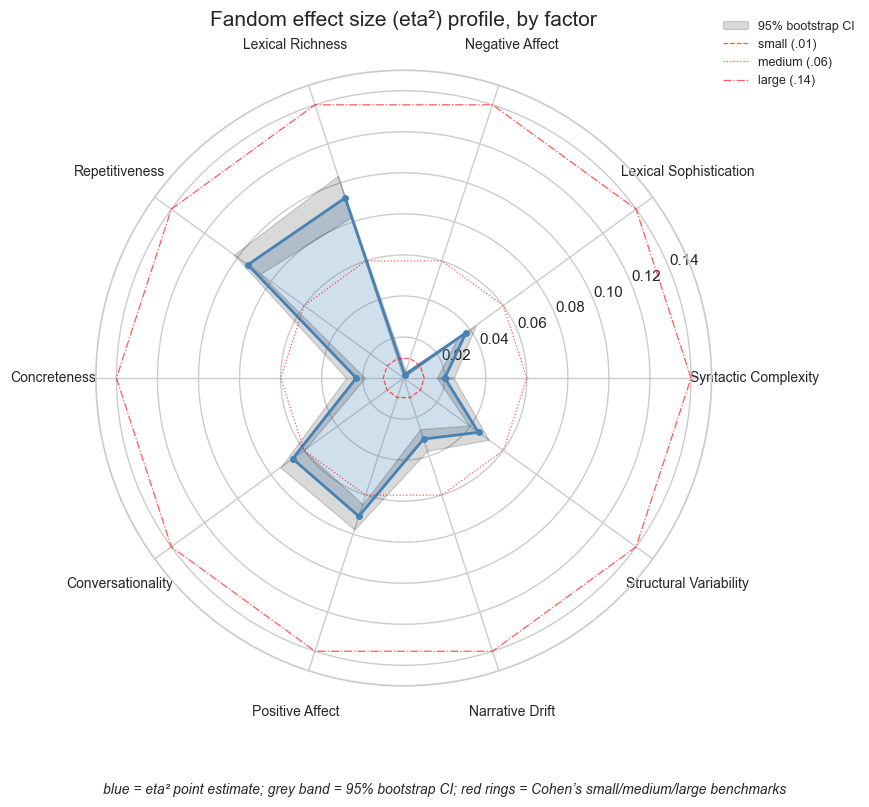

In [106]:
# same data as the bar chart above, as a radar/spider profile -- matches the
# visual language of the fandom/rating factor-score radars elsewhere in this
# notebook. eta2 is always >= 0, so no negative-radius offset hack is needed
# here (unlike those charts).
fbf_ordered = fandom_by_factor.set_index('factor').loc[FACTOR_COLS].reset_index()
labels = [FACTOR_NAMES[f] for f in FACTOR_COLS]
n_vars = len(FACTOR_COLS)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

eta2_vals = fbf_ordered['eta2'].tolist() + [fbf_ordered['eta2'].iloc[0]]
lo_vals = fbf_ordered['eta2_lo95'].tolist() + [fbf_ordered['eta2_lo95'].iloc[0]]
hi_vals = fbf_ordered['eta2_hi95'].tolist() + [fbf_ordered['eta2_hi95'].iloc[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

ax.fill(angles, eta2_vals, color='steelblue', alpha=0.25)
ax.plot(angles, eta2_vals, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(angles, lo_vals, hi_vals, color='black', alpha=0.15, label='95% bootstrap CI')

r_max = max(0.15, fbf_ordered['eta2_hi95'].max() * 1.1)
ring_style = [(0.01, 'small (.01)', '--'), (0.06, 'medium (.06)', ':'), (0.14, 'large (.14)', '-.')]
for thresh, lbl, ls in ring_style:
    if thresh <= r_max:
        ax.plot(angles, [thresh] * len(angles), color='red', linewidth=0.9, linestyle=ls, alpha=0.65, label=lbl)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='medium')
ax.set_ylim(0, r_max)
ax.tick_params(axis='x', pad=18)
ax.set_title('Fandom effect size (eta\u00b2) profile, by factor', fontsize=15, pad=32)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=9, frameon=False)
fig.text(0.5, 0.02, 'blue = eta\u00b2 point estimate; grey band = 95% bootstrap CI; red rings = Cohen\u2019s small/medium/large benchmarks',
          ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(VIS_DIR / 'fandom_factor_eta2_radar.png', dpi=300, bbox_inches='tight')
plt.show()

### Side-by-side comparison

Same data as the radar charts above, but laid out as a heatmap — fandoms as rows, factors as columns — so you can scan across a row to see one fandom's full profile, or down a column to compare all fandoms on a single factor, without the visual indirection of the polar shapes.

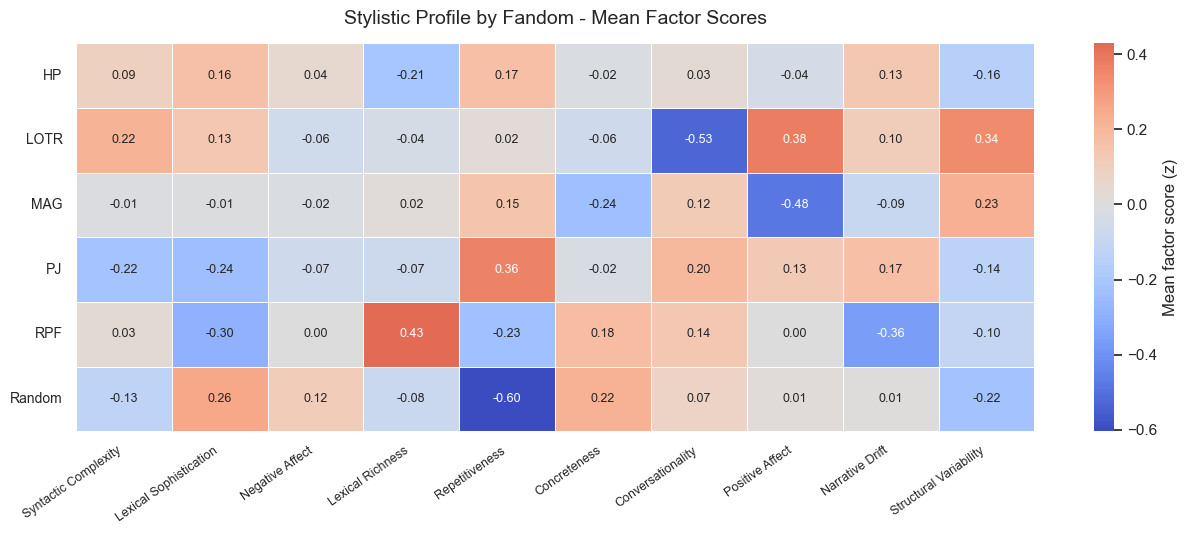

In [103]:
heatmap_data = fandom_means[FACTOR_COLS].rename(columns=FACTOR_NAMES)
heatmap_data.index = [FANDOM_DISPLAY[f] for f in heatmap_data.index]
heatmap_data = heatmap_data.loc[[FANDOM_DISPLAY[f] for f in FANDOM_ORDER]]

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.6, linecolor='white', ax=ax, cbar_kws={'label': 'Mean factor score (z)'},
    annot_kws={'fontsize': 9}
)
ax.set_title('Stylistic Profile by Fandom - Mean Factor Scores', fontsize=14, pad=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(VIS_DIR / 'fandom_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

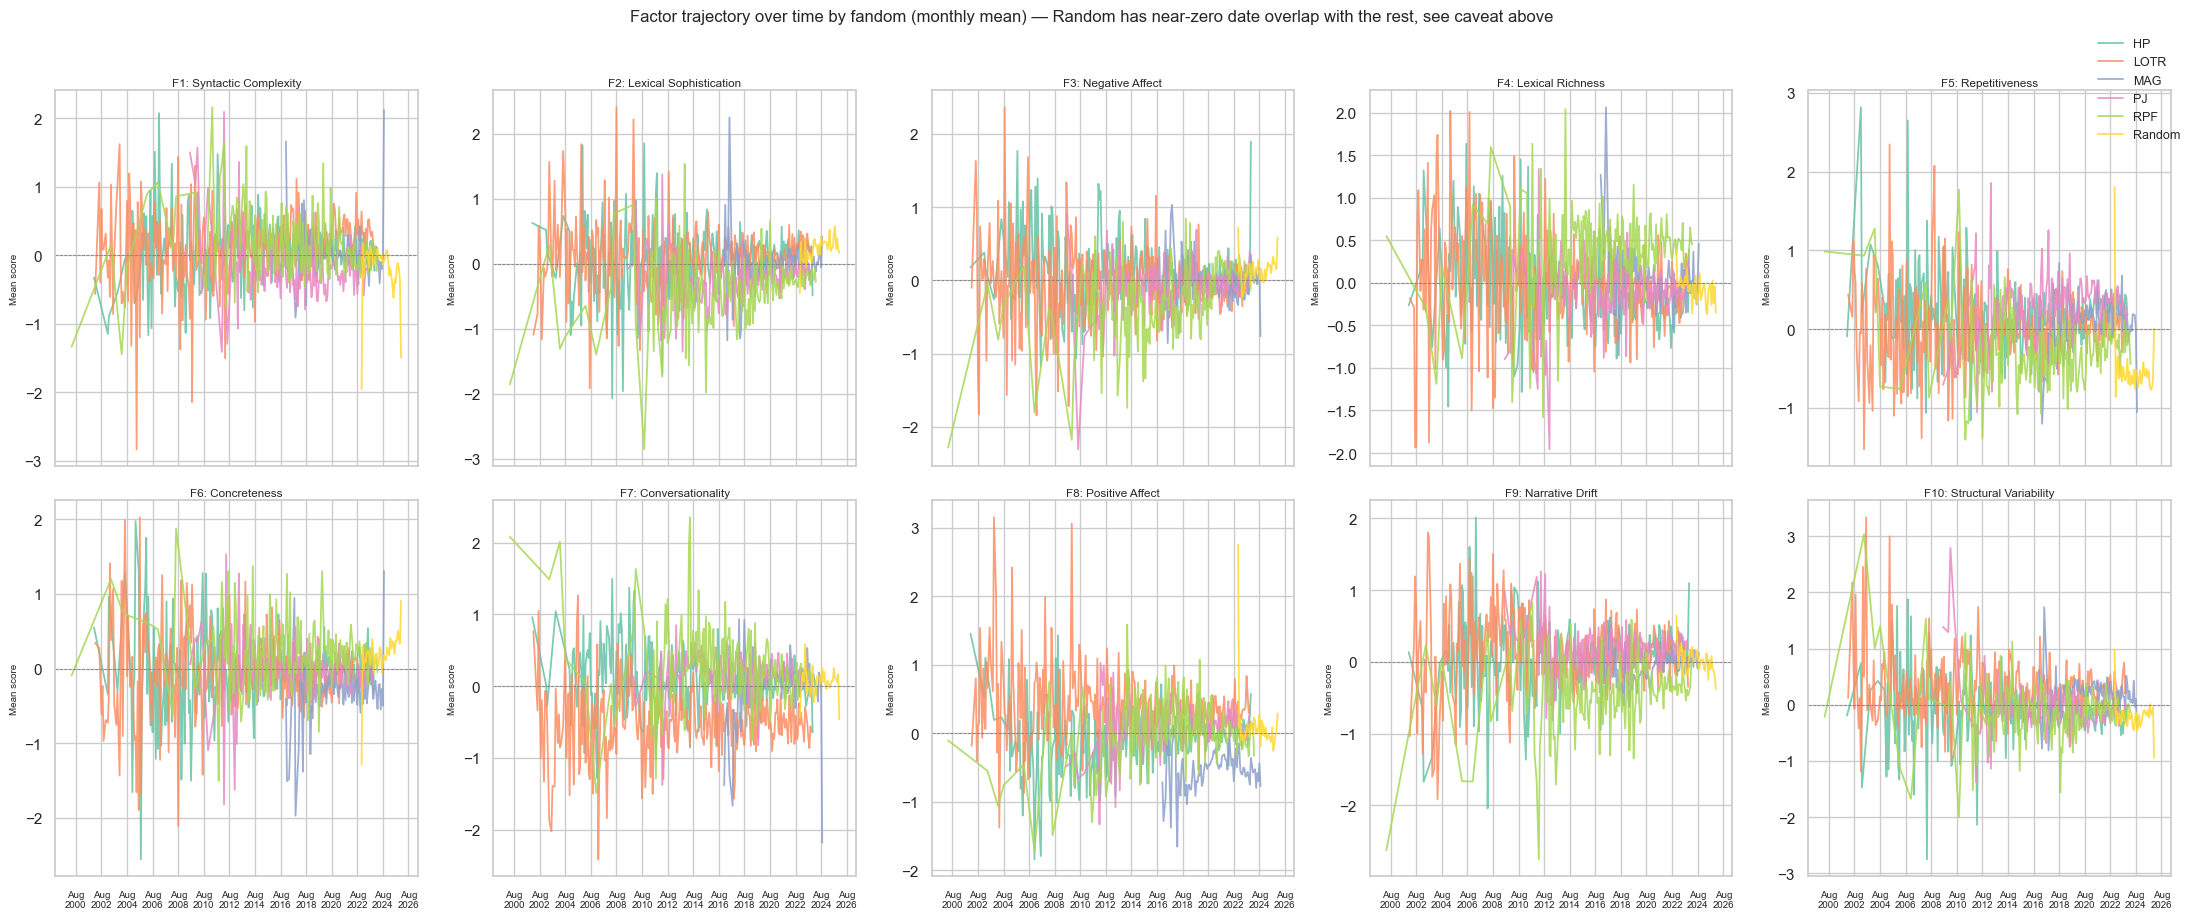

In [104]:
fandom_monthly = (
    df.groupby(['year_month', 'fandom_label'], observed=True)[FACTOR_COLS]
    .mean()
    .reset_index()
)
fandom_monthly['date'] = fandom_monthly['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharex=True)
axes = axes.flatten()
pal = dict(zip(FANDOM_ORDER, sns.color_palette('Set2', n_colors=len(FANDOM_ORDER))))

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    for fandom in FANDOM_ORDER:
        sub = fandom_monthly[fandom_monthly['fandom_label'] == fandom]
        ax.plot(sub['date'], sub[f], label=FANDOM_DISPLAY[fandom], color=pal[fandom],
                linewidth=1.3, alpha=0.85)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
    ax.tick_params(axis='x', labelsize=7)
    ax.set_ylabel('Mean score', fontsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER],
           loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9, frameon=False)

plt.suptitle('Factor trajectory over time by fandom (monthly mean) — Random has near-zero date overlap with the rest, see caveat above', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_trajectory_by_fandom.png', dpi=300, bbox_inches='tight')
plt.show()

### Trajectory on a common developmental axis (min-max normalized time)

The plot above uses raw calendar dates, which is exactly what the caveat above warns about: `random` barely overlaps in time with the other five fandoms, so any apparent joint "trend" there is a date-window artifact, not a real signal.

Fix: normalize `published` to [0, 1] **within each fandom separately** (0 = that fandom's earliest text, 1 = its most recent) — the same `published_norm` construction `dispersion_regression.R` uses as its `time` predictor throughout the whole convergence/divergence analysis. Every fandom now sits on a common "relative position in its own lifecycle" axis, so shapes are comparable across fandoms even though the underlying calendar windows aren't. Bins are equal-*count* (percentile-based, matching the `ntile()` binning used in that R analysis) rather than equal-width, since text density rises sharply over time within most fandoms and equal-width calendar bins would leave the early bins very sparse.

**Reading it**: the x-axis no longer means "this calendar date" — it means "this far into the fandom's observed lifespan." Don't compare x-positions across fandoms as if they were the same real-world year.

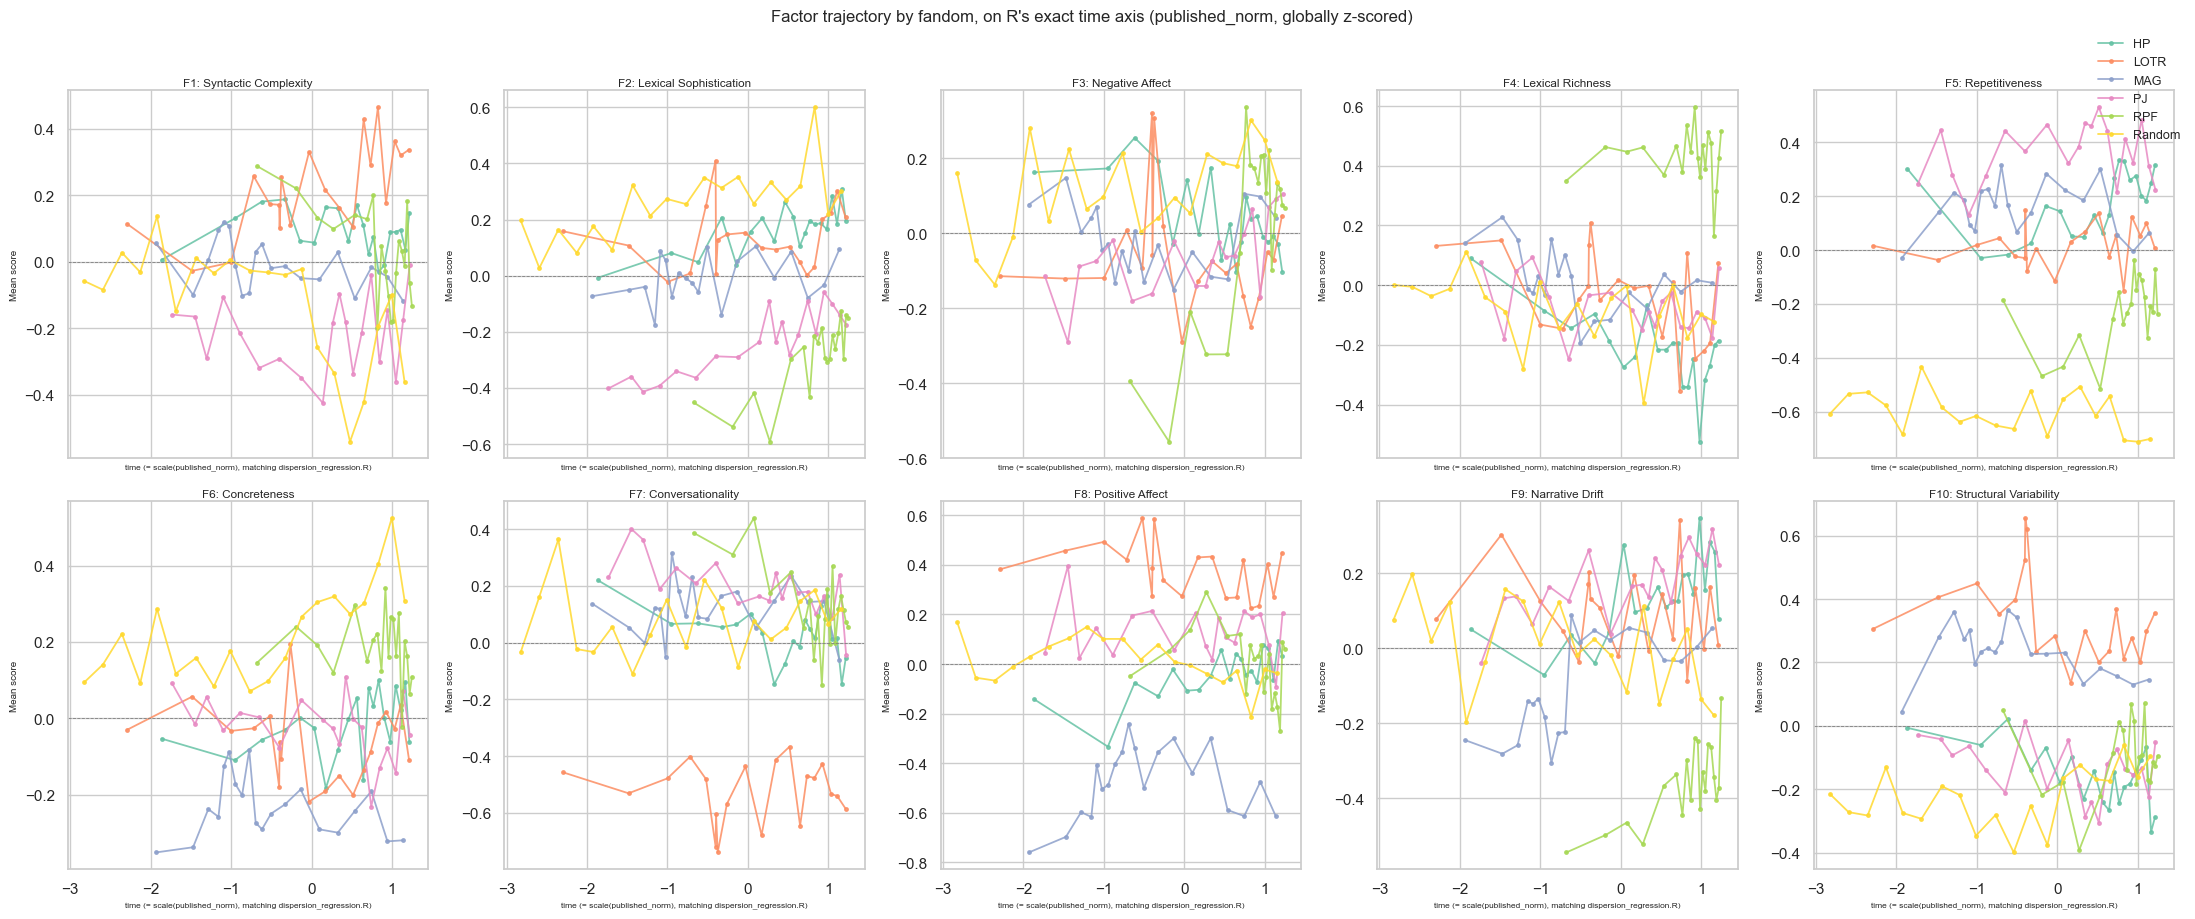

In [105]:
N_BINS = 20

# exact match to dispersion_regression.R's construction:
#   published_norm = min-max normalized WITHIN fandom to [0,1]
#   time           = published_norm, then z-scored GLOBALLY (scale(), all
#                    fandoms pooled) -- not per-fandom.
# Verified this doesn't dilute any fandom-specific pattern: global z-scoring
# is the same linear transform applied to every row, so it divides every
# fandom's own slope by the identical constant and leaves every p-value
# bit-for-bit unchanged (checked directly against the real data before
# adopting this). Bin assignment (percentile rank within fandom) is also
# unaffected, since it's a monotonic transform.
df['published_num'] = df['published'].astype('int64')
df['published_norm'] = df.groupby('fandom_label', observed=True)['published_num'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
df['time'] = (df['published_norm'] - df['published_norm'].mean()) / df['published_norm'].std()

df['time_pctile'] = df.groupby('fandom_label', observed=True)['time'].rank(pct=True)
df['time_bin'] = (df['time_pctile'] * N_BINS).clip(upper=N_BINS - 1e-9).astype(int)

fandom_time_binned = (
    df.groupby(['fandom_label', 'time_bin'], observed=True)
    .agg(time_mid=('time', 'mean'),
         n=(FACTOR_COLS[0], 'count'),
         **{f: (f, 'mean') for f in FACTOR_COLS})
    .reset_index()
)

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharex=True)
axes = axes.flatten()
pal = dict(zip(FANDOM_ORDER, sns.color_palette('Set2', n_colors=len(FANDOM_ORDER))))

for i, f in enumerate(FACTOR_COLS):
    ax = axes[i]
    for fandom in FANDOM_ORDER:
        sub = fandom_time_binned[fandom_time_binned['fandom_label'] == fandom].sort_values('time_mid')
        ax.plot(sub['time_mid'], sub[f], label=FANDOM_DISPLAY[fandom], color=pal[fandom],
                linewidth=1.3, alpha=0.85, marker='o', markersize=2.5)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_title(f'{f}: {FACTOR_NAMES[f]}', fontsize=8.5, pad=3)
    ax.set_xlabel("time (= scale(published_norm), matching dispersion_regression.R)", fontsize=6)
    ax.set_ylabel('Mean score', fontsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [FANDOM_DISPLAY[fd] for fd in FANDOM_ORDER],
           loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9, frameon=False)

plt.suptitle("Factor trajectory by fandom, on R's exact time axis (published_norm, globally z-scored)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(VIS_DIR / 'factor_trajectory_by_fandom_normtime.png', dpi=300, bbox_inches='tight')
plt.show()